<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Подготовим данные для обучения

In [ ]:
import pandas as pd

# Путь к файлу
path = "/content/drive/MyDrive/data_problems_translated.xlsx"

# Чтение файла
df = pd.read_excel(path)

# Удаляем дубликаты по тексту задачи
df_clean = df.drop_duplicates(subset=['problem_text'])

print(f"Было: {len(df)} строк")
print(f"Стало: {len(df_clean)} строк")
print(f"Удалено: {len(df) - len(df_clean)} дубликатов")
df=df_clean
print(f"Окончательно: {len(df)} строк")

Было: 5273 строк
Стало: 4319 строк
Удалено: 954 дубликатов
Окончательно: 4319 строк


Преобразуем текстовые метки в числовые

In [ ]:
# Создаем словарь для маппинга тем в индексы
unique_topics = df['topic'].unique()
topic_to_id = {topic: idx for idx, topic in enumerate(unique_topics)}
id_to_topic = {idx: topic for topic, idx in topic_to_id.items()}

# Добавляем колонку с числовыми метками
df['label'] = df['topic'].map(topic_to_id)

print("Классы и их количество:")
print(df['topic'].value_counts())
print(f"\nВсего классов: {len(unique_topics)}")

Классы и их количество:
topic
number_theory    2156
combinatorics     743
polynoms          380
geometry          364
dirichlet         344
invariant         172
graphs            160
Name: count, dtype: int64

Всего классов: 7


Разделим исходные данные на train, validation и test

In [ ]:
from sklearn.model_selection import train_test_split

# Разделение с сохранением пропорций классов (стратификация)
train_df, val_df = train_test_split(
    df,
    test_size=0.3,  # 30% на val+test
    random_state=42,
    stratify=df['label']
)
print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")

Train: 3023 samples
Val: 1296 samples


Создаем Dataloaderы

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

class MathProblemsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'inputs': {k: v.squeeze(0) for k, v in encoding.items()},
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Инициализация токенизатора
ruberttiny_tokenizer = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')
mathbert_tokenizer = AutoTokenizer.from_pretrained('tbs17/MathBert')
# Создание датасетов
# ДЛЯ cointegrated/rubert-tiny2
train_dataset_rubert = MathProblemsDataset(
    train_df['problem_text'].values,
    train_df['label'].values,
    ruberttiny_tokenizer
)
val_dataset_rubert = MathProblemsDataset(
    val_df['problem_text'].values,
    val_df['label'].values,
    ruberttiny_tokenizer
)
# ДЛЯ tbs17/MathBert
train_dataset_math = MathProblemsDataset(
    train_df['problem_text'].values,
    train_df['label'].values,
    mathbert_tokenizer,
    max_length=256
)

val_dataset_math = MathProblemsDataset(
    val_df['problem_text'].values,
    val_df['label'].values,
    mathbert_tokenizer,
    max_length=256
)
# Создание даталоадеров
BATCH_SIZE = 16
# ДЛЯ cointegrated/rubert-tiny2
train_dataloader_rubert = DataLoader(train_dataset_rubert, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader_rubert = DataLoader(val_dataset_rubert, batch_size=BATCH_SIZE, shuffle=False)
# ДЛЯ tbs17/MathBert
train_dataloader_math = DataLoader(train_dataset_math, batch_size=BATCH_SIZE, shuffle=True)
val_dataloader_math = DataLoader(val_dataset_math, batch_size=BATCH_SIZE, shuffle=False)

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel
from typing import Union

In [ ]:
### This is just an interface example. You may change it if you want.

class TransformerClassificationModel(nn.Module):
    def __init__(self, base_transformer_model: Union[str, nn.Module], num_classes):
        super(TransformerClassificationModel, self).__init__()
        #создаем и сохраняем предобученный трансформер
        if isinstance(base_transformer_model, str):
          self.backbone = AutoModel.from_pretrained(base_transformer_model, output_attentions=True)
        else:
          self.backbone = base_transformer_model
        #получаем размер эмбеддинга
        hidden_size = self.backbone.config.hidden_size
        #добавляем классификатор
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),  # промежуточный слой
            nn.ReLU(),                     # нелинейность
            nn.Dropout(0.3),              # регуляризация
            nn.Linear(256, num_classes)   # выходной слой
            )
        # YOUR CODE: create additional layers for classfication

    def forward(self, inputs):
        # YOUR CODE: propagate inputs through the model. Return dict with logits
        #распаковка словаря
        backbone_outputs = self.backbone(**inputs)
        #подход с токеном [cls]
        cls_embedding = backbone_outputs.last_hidden_state[:, 0, :]
        #пропускаем через линейный слой
        logits = self.classifier(cls_embedding)
        outputs = {'logits': logits}
        return outputs

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [ ]:
def freeze_backbone_function(model: TransformerClassificationModel):
  #проходим по все параметрам backbone и отключаем градиенты
  for param in model.backbone.parameters():
    param.requires_grad = False
  #возвращаем модель
  return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [ ]:
import copy
import torch
import torch.nn as nn
from tqdm import tqdm

def train_transformer(transformer_model, train_dataloader, val_dataloader=None,
                      freeze_backbone=True, num_epochs=5, learning_rate=2e-5):

    # Создаем копию модели
    model = copy.deepcopy(transformer_model)

    # Настройка заморозки
    if freeze_backbone:
        model = freeze_backbone_function(model)
    else:
        for param in model.backbone.parameters():
            param.requires_grad = True

    # Устройство
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Устройство: {device}')
    model = model.to(device)

    # Функция потерь
    criterion = nn.CrossEntropyLoss()

    # Оптимизатор
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    # Планировщик learning rate
    total_steps = len(train_dataloader) * num_epochs
    scheduler = torch.optim.lr_scheduler.LinearLR(
        optimizer,
        start_factor=1.0,
        end_factor=0.1,
        total_iters=total_steps
    )

    # История обучения
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_accuracy': []
    }

    # Цикл обучения
    for epoch in range(num_epochs):
        print(f"\n=== Эпоха {epoch + 1}/{num_epochs} ===")
        model.train()
        total_train_loss = 0
        train_steps = 0

        train_iterator = tqdm(train_dataloader, desc=f"Обучение эпоха {epoch+1}")

        for batch in train_iterator:
            # Перенос данных на устройство
            inputs = {key: value.to(device) for key, value in batch['inputs'].items()}
            labels = batch['labels'].to(device)

            # Обнуление градиентов
            optimizer.zero_grad()

            # Прямой проход
            outputs = model(inputs)
            logits = outputs['logits']

            # Вычисление loss
            loss = criterion(logits, labels)

            # Обратный проход
            loss.backward()

            # Обновление весов
            optimizer.step()

            # Шаг планировщика
            scheduler.step()

            # Статистика
            total_train_loss += loss.item()
            train_steps += 1

            # Обновление прогресс-бара
            train_iterator.set_postfix({'loss': f'{loss.item():.4f}'})

        avg_train_loss = total_train_loss / train_steps
        history['train_loss'].append(avg_train_loss)
        print(f"Средний train loss: {avg_train_loss:.4f}")

        # Валидация
        if val_dataloader:
            model.eval()
            total_val_loss = 0
            correct_predictions = 0
            total_predictions = 0
            val_steps = 0

            val_iterator = tqdm(val_dataloader, desc=f"Валидация эпоха {epoch+1}")

            with torch.no_grad():
                for batch in val_iterator:
                    # Перенос данных на устройство
                    inputs = {key: value.to(device) for key, value in batch['inputs'].items()}
                    labels = batch['labels'].to(device)

                    # Прямой проход
                    outputs = model(inputs)
                    logits = outputs['logits']

                    # Вычисление loss
                    loss = criterion(logits, labels)
                    total_val_loss += loss.item()

                    # Вычисление accuracy
                    predictions = torch.argmax(logits, dim=1)
                    correct_predictions += (predictions == labels).sum().item()
                    total_predictions += labels.size(0)

                    val_steps += 1

                    # Обновление прогресс-бара
                    current_acc = correct_predictions / total_predictions
                    val_iterator.set_postfix({
                        'loss': f'{loss.item():.4f}',
                        'acc': f'{current_acc:.4f}'
                    })

            avg_val_loss = total_val_loss / val_steps
            val_accuracy = correct_predictions / total_predictions

            history['val_loss'].append(avg_val_loss)
            history['val_accuracy'].append(val_accuracy)

            print(f"Средний val loss: {avg_val_loss:.4f}")
            print(f"Val accuracy: {val_accuracy:.4f}")

    print("\nОбучение завершено!")
    return model, history

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [ ]:
num_classes = len(unique_topics)
print(f"Количество классов: {num_classes}")

# Создаем базовую модель
base_model = TransformerClassificationModel('cointegrated/rubert-tiny2', num_classes)

#-----------------------------------------------------
print("=" * 60)
print("ОБУЧЕНИЕ С ЗАМОРОЖЕННЫМ BACKBONE (rubert-tiny2)")
print("=" * 60)

model_frozen = copy.deepcopy(base_model)
model_frozen = freeze_backbone_function(model_frozen)

rubert_tiny_frozen, history_frozen = train_transformer(
    transformer_model=model_frozen,
    train_dataloader=train_dataloader_rubert,
    val_dataloader=val_dataloader_rubert,
    freeze_backbone=True,
    num_epochs=5,
    learning_rate=2e-5
)

#-----------------------------------------------------
print("=" * 60)
print("ОБУЧЕНИЕ С РАЗМОРОЖЕННЫМ BACKBONE (rubert-tiny2)")
print("=" * 60)

model_unfrozen = copy.deepcopy(base_model)

rubert_tiny_unfrozen, history_unfrozen = train_transformer(
    transformer_model=model_unfrozen,
    train_dataloader=train_dataloader_rubert,
    val_dataloader=val_dataloader_rubert,
    freeze_backbone=False,
    num_epochs=5,
    learning_rate=2e-5
)

Количество классов: 7


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ОБУЧЕНИЕ С ЗАМОРОЖЕННЫМ BACKBONE (rubert-tiny2)
Устройство: cuda

=== Эпоха 1/5 ===


Обучение эпоха 1: 100%|██████████| 189/189 [00:05<00:00, 36.57it/s, loss=1.8257]


...

Средний val loss: 0.9714
Val accuracy: 0.6721

=== Эпоха 5/5 ===


Обучение эпоха 5: 100%|██████████| 189/189 [00:11<00:00, 15.97it/s, loss=0.8403]


Средний train loss: 0.9587


Валидация эпоха 5: 100%|██████████| 81/81 [00:02<00:00, 34.21it/s, loss=1.3716, acc=0.6752]

Средний val loss: 0.9587
Val accuracy: 0.6752

Обучение завершено!


### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [ ]:
num_classes = len(unique_topics)
print(f"Количество классов: {num_classes}")

# Создаем базовую модель MathBert
mathbert_base = TransformerClassificationModel('tbs17/MathBert', num_classes)

# ============================================================
# ЭКСПЕРИМЕНТ 1: MathBert с ЗАМОРОЖЕННЫМ backbone
# ============================================================
print("=" * 60)
print("ОБУЧЕНИЕ MathBert С ЗАМОРОЖЕННЫМ BACKBONE")
print("=" * 60)

mathbert_frozen_model = copy.deepcopy(mathbert_base)
mathbert_frozen_model = freeze_backbone_function(mathbert_frozen_model)

mathbert_frozen, history_mathbert_frozen = train_transformer(
    transformer_model=mathbert_frozen_model,
    train_dataloader=train_dataloader_math,
    val_dataloader=val_dataloader_math,
    freeze_backbone=True,
    num_epochs=5,
    learning_rate=2e-5
)

# ============================================================
# ЭКСПЕРИМЕНТ 2: MathBert с РАЗМОРОЖЕННЫМ backbone
# ============================================================
print("=" * 60)
print("ОБУЧЕНИЕ MathBert С РАЗМОРОЖЕННЫМ BACKBONE")
print("=" * 60)

mathbert_unfrozen_model = copy.deepcopy(mathbert_base)

mathbert_unfrozen, history_mathbert_unfrozen = train_transformer(
    transformer_model=mathbert_unfrozen_model,
    train_dataloader=train_dataloader_math,
    val_dataloader=val_dataloader_math,
    freeze_backbone=False,
    num_epochs=5,
    learning_rate=2e-5
)

Количество классов: 7


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ОБУЧЕНИЕ MathBert С ЗАМОРОЖЕННЫМ BACKBONE
Устройство: cuda

=== Эпоха 1/5 ===


Обучение эпоха 1: 100%|██████████| 189/189 [00:46<00:00,  4.04it/s, loss=1.5392]


...

Средний val loss: 0.8971
Val accuracy: 0.7168

=== Эпоха 5/5 ===


Обучение эпоха 5: 100%|██████████| 189/189 [02:14<00:00,  1.41it/s, loss=0.2645]


Средний train loss: 0.2026


Валидация эпоха 5: 100%|██████████| 81/81 [00:20<00:00,  4.01it/s, loss=1.4220, acc=0.7130]

Средний val loss: 0.9497
Val accuracy: 0.7130

Обучение завершено!


 Использование MathBert дало лучшие результаты по сравнению с rubert-tiny2 в обоих режимах обучения (замороженном и размороженном). Это объясняется тем, что MathBert была предобучена на специализированном корпусе математических текстов (научные статьи, учебники, математические форумы). Следовательно, она уже изначально обладала более релевантными признаками для анализа математических задач, что позволило ей эффективнее адаптироваться к целевой задаче в процессе дообучения и достичь более высокой точности классификации.

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [ ]:
import matplotlib.pyplot as plt
import torch
from typing import List

def draw_first_layer_attention_maps(text, model, tokenizer, cmap='Blues', title_prefix=''):
    model.eval()
    device = next(model.parameters()).device

    # Токенизация
    encoding = tokenizer(text, return_tensors='pt', truncation=True, max_length=128)
    inputs = {k: v.to(device) for k, v in encoding.items()}
    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

    # Включаем attention в конфиге
    original_config = model.backbone.config.output_attentions
    model.backbone.config.output_attentions = True

    # Прямой проход
    with torch.no_grad():
        backbone_outputs = model.backbone(**inputs)

    # Возвращаем конфиг
    model.backbone.config.output_attentions = original_config

    # Получаем attention первого слоя
    attention = backbone_outputs.attentions[0][0].cpu().numpy()  # [12, seq_len, seq_len]

    # Создаем сетку 3x4
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    # Обрезаем длинные токены для читаемости
    tokens_short = [t.replace('##', '')[:6] for t in tokens]

    for head_id in range(12):
        ax = axes[head_id]
        attn = attention[head_id]

        im = ax.imshow(attn, cmap=cmap, aspect='auto')
        ax.set_xticks(range(len(tokens_short)))
        ax.set_yticks(range(len(tokens_short)))
        ax.set_xticklabels(tokens_short, rotation=90, fontsize=7)
        ax.set_yticklabels(tokens_short, fontsize=7)
        ax.set_title(f'Голова {head_id}', fontsize=10)

    plt.tight_layout()
    plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [ ]:
# Выбираем 3 текста из val_df (по одному из разных тем для разнообразия)
sample_texts = val_df['problem_text'].values[:3]
sample_labels = val_df['label'].values[:3]
sample_topics = val_df['topic'].values[:3]

print("Выбранные тексты для анализа:")
for i, (text, topic) in enumerate(zip(sample_texts, sample_topics)):
    print(f"\n{i+1}. Тема: {topic}")
    print(f"   {text[:150]}...")

Выбранные тексты для анализа:

1. Тема: number_theory
   If a is b (mod m), n is the natural number, an is bn (mod m)....

2. Тема: combinatorics
   There are 40 signs in the row: 20 crucifixes and 20 nils. You can change the order of any two adjacent signs in one move. For what is the lowest numbe...

3. Тема: number_theory
   Can all natural number dividers of 100! (including 1 and the number itself) be divided into two groups so that in both groups the number of numbers is...


In [ ]:
num_classes = len(unique_topics)

# Создаем свежие модели (без обучения)
rubert_raw = TransformerClassificationModel('cointegrated/rubert-tiny2', num_classes)
mathbert_raw = TransformerClassificationModel('tbs17/MathBert', num_classes)

print("модели загружены")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


модели загружены


для rubert-tiny2 ДО обучения

rubert-tiny2 ДО ОБУЧЕНИЯ

######################################################################
Текст 1: number_theory
If a is b (mod m), n is the natural number, an is bn (mod m)....
######################################################################


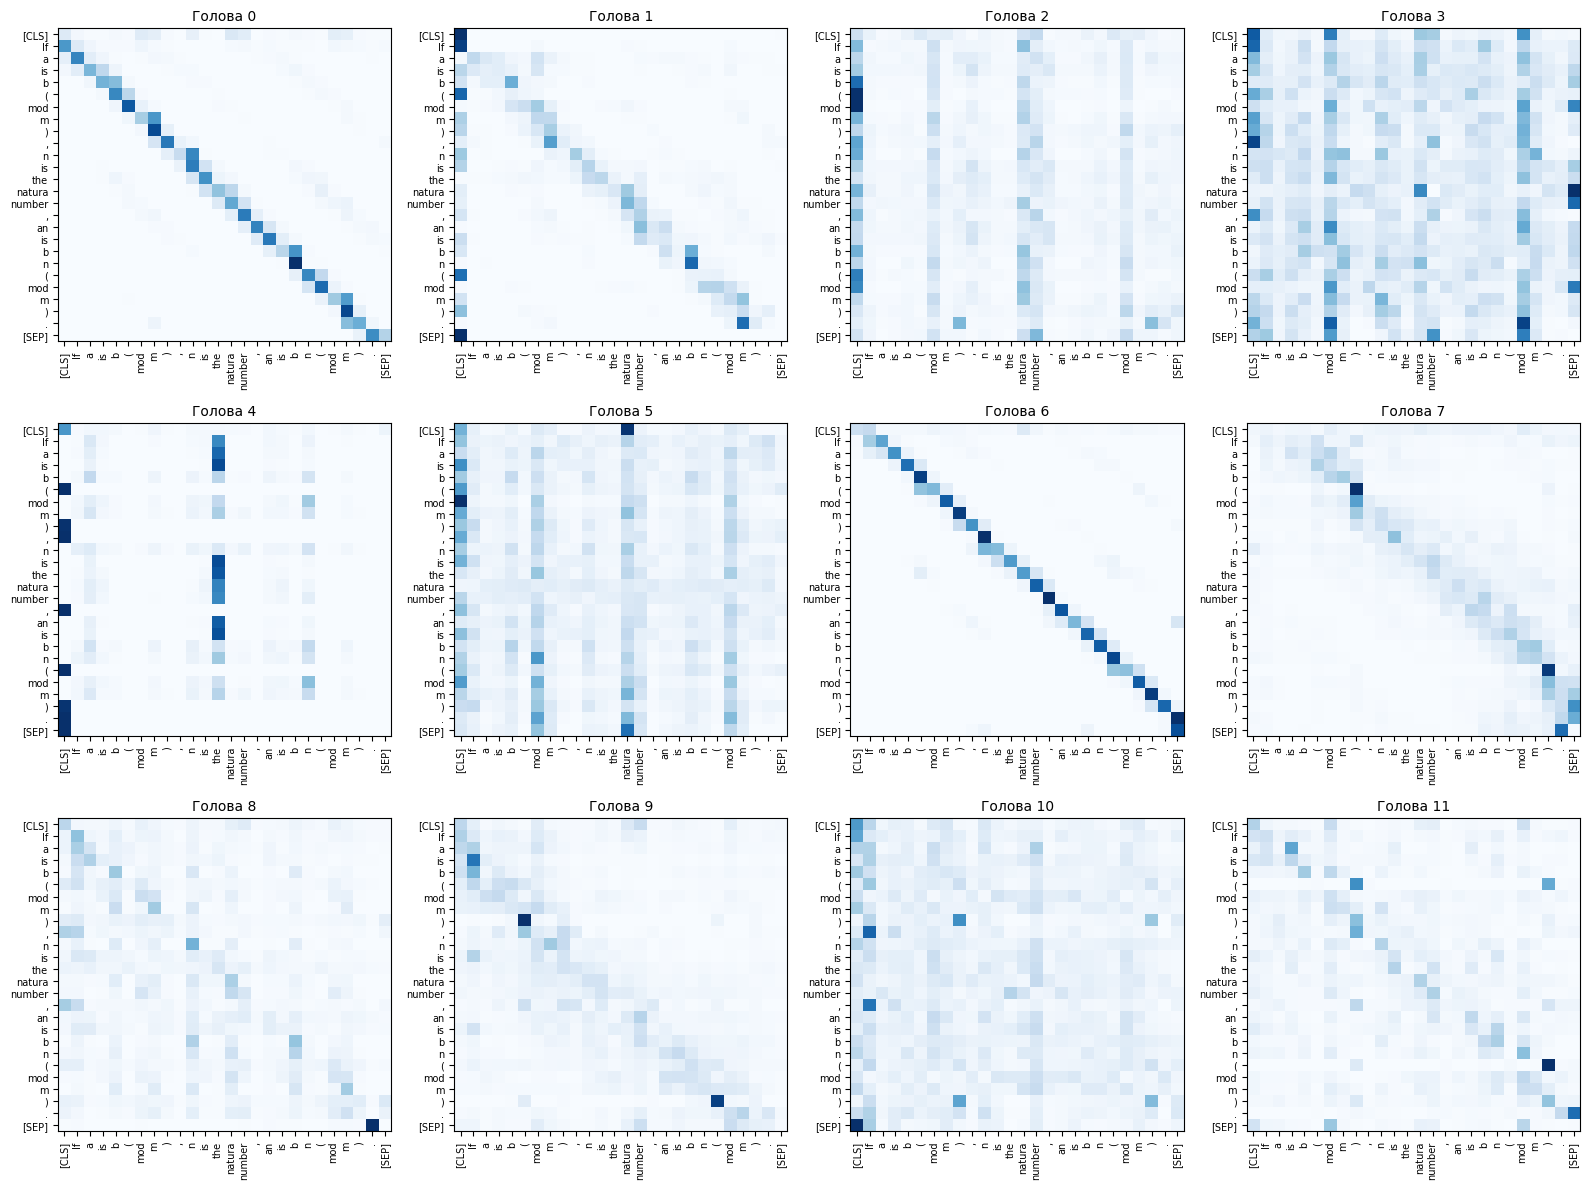


######################################################################
Текст 2: combinatorics
There are 40 signs in the row: 20 crucifixes and 20 nils. You can change the order of any two adjace...
######################################################################


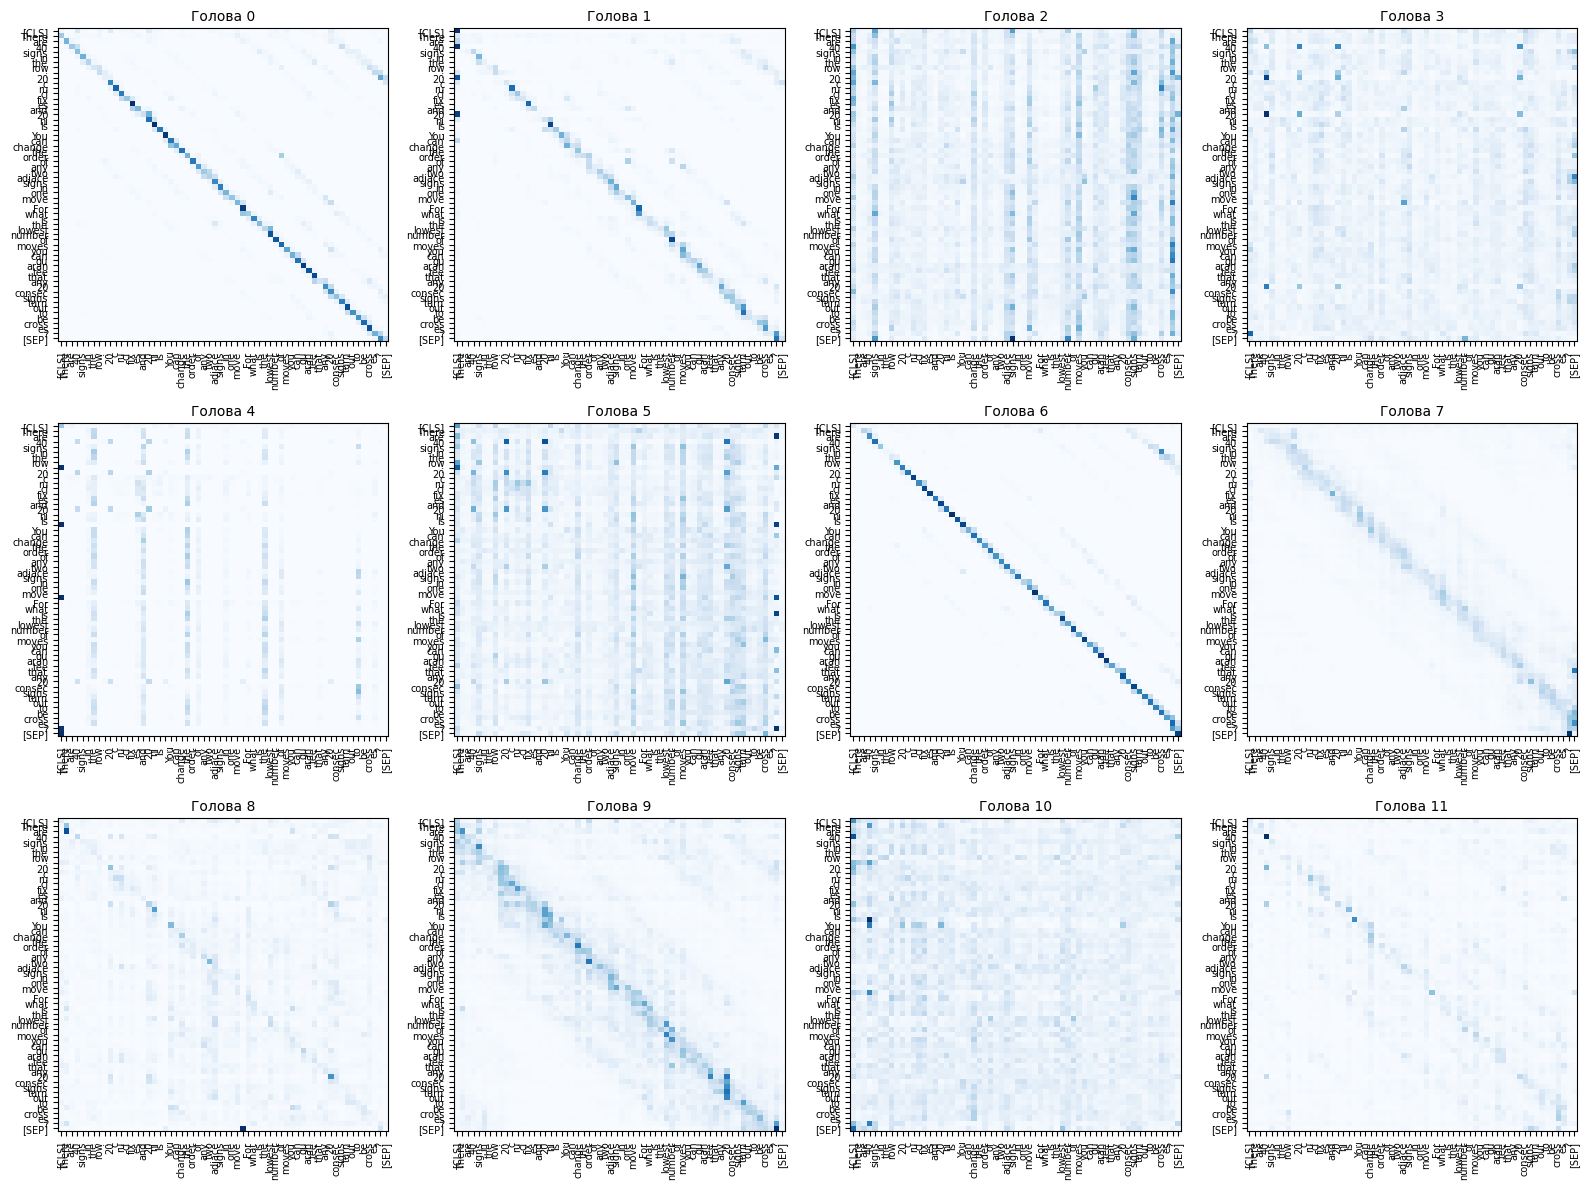


######################################################################
Текст 3: number_theory
Can all natural number dividers of 100! (including 1 and the number itself) be divided into two grou...
######################################################################


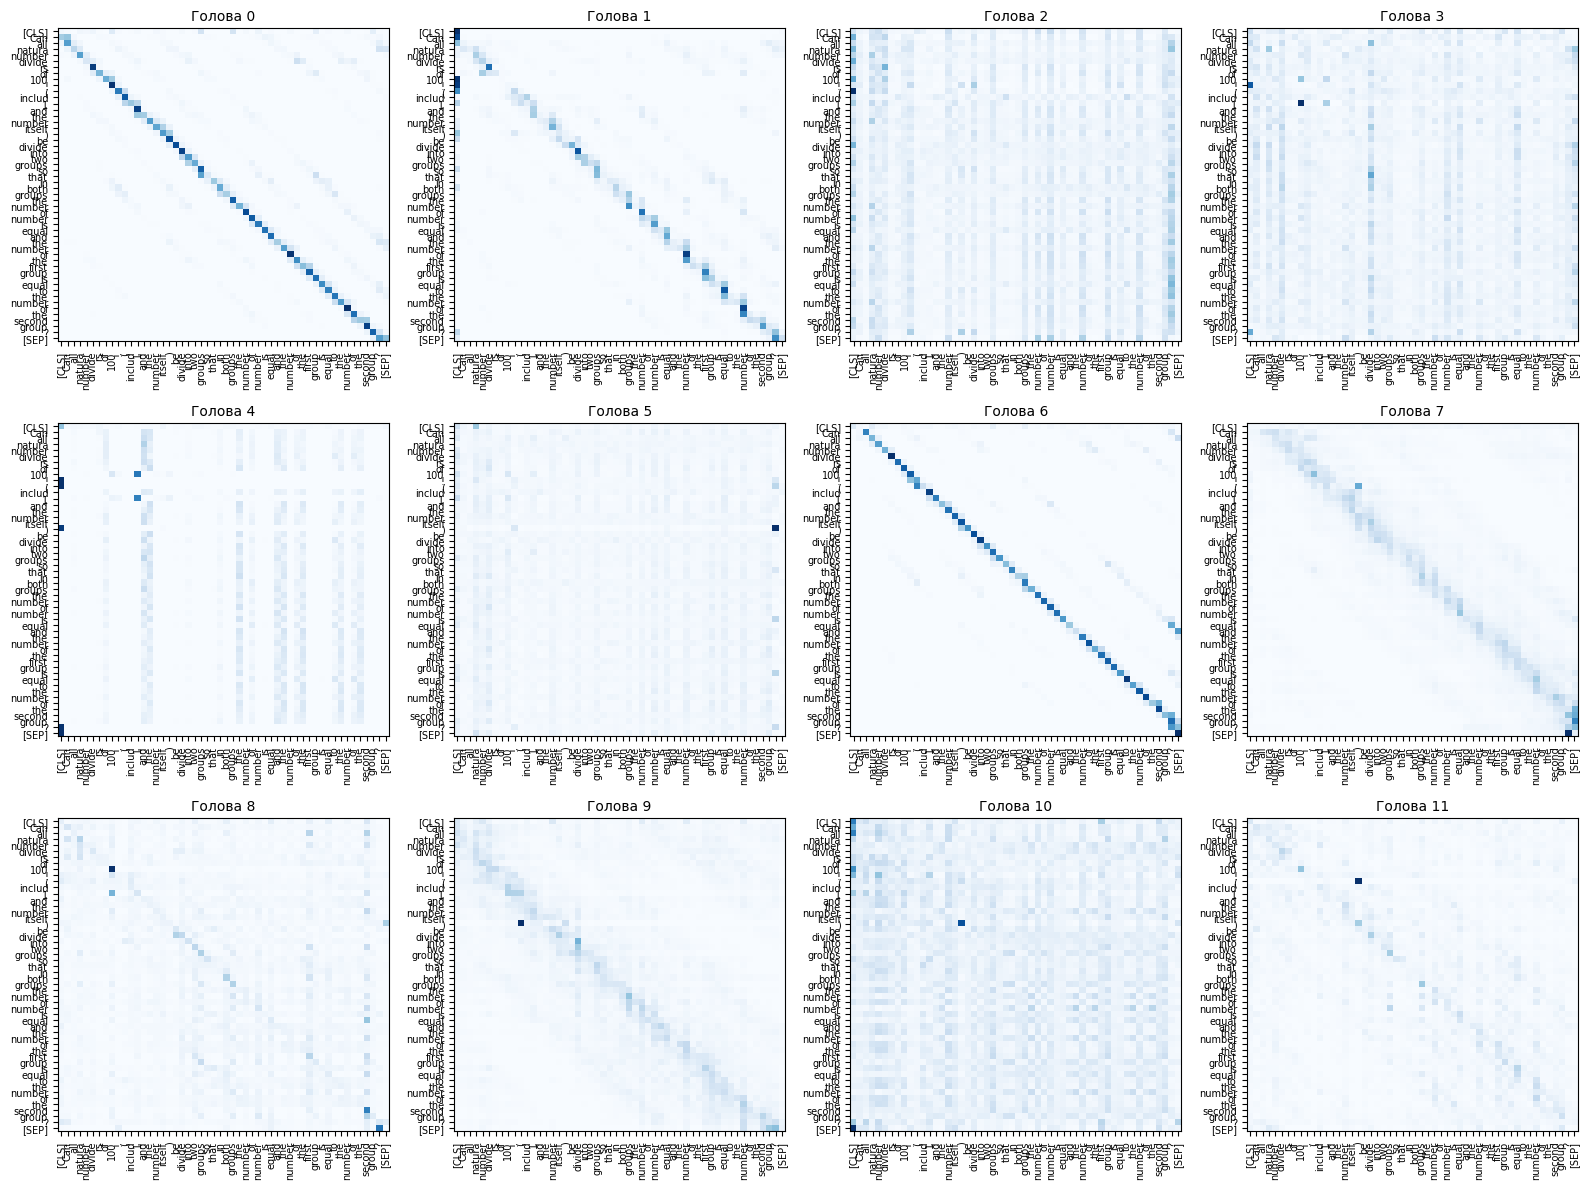

In [ ]:
print("rubert-tiny2 ДО ОБУЧЕНИЯ")

for i, (text, topic) in enumerate(zip(sample_texts, sample_topics)):
    print(f"\n{'#'*70}")
    print(f"Текст {i+1}: {topic}")
    print(f"{text[:100]}...")
    print(f"{'#'*70}")

    draw_first_layer_attention_maps(
        text=text,
        model=rubert_raw,
        tokenizer=ruberttiny_tokenizer,
        cmap='Blues', title_prefix='ДО ОБУЧЕНИЯ'
    )

для MathBert ДО обучения

MathBert ДО ОБУЧЕНИЯ

######################################################################
Текст 1: number_theory
If a is b (mod m), n is the natural number, an is bn (mod m)....
######################################################################


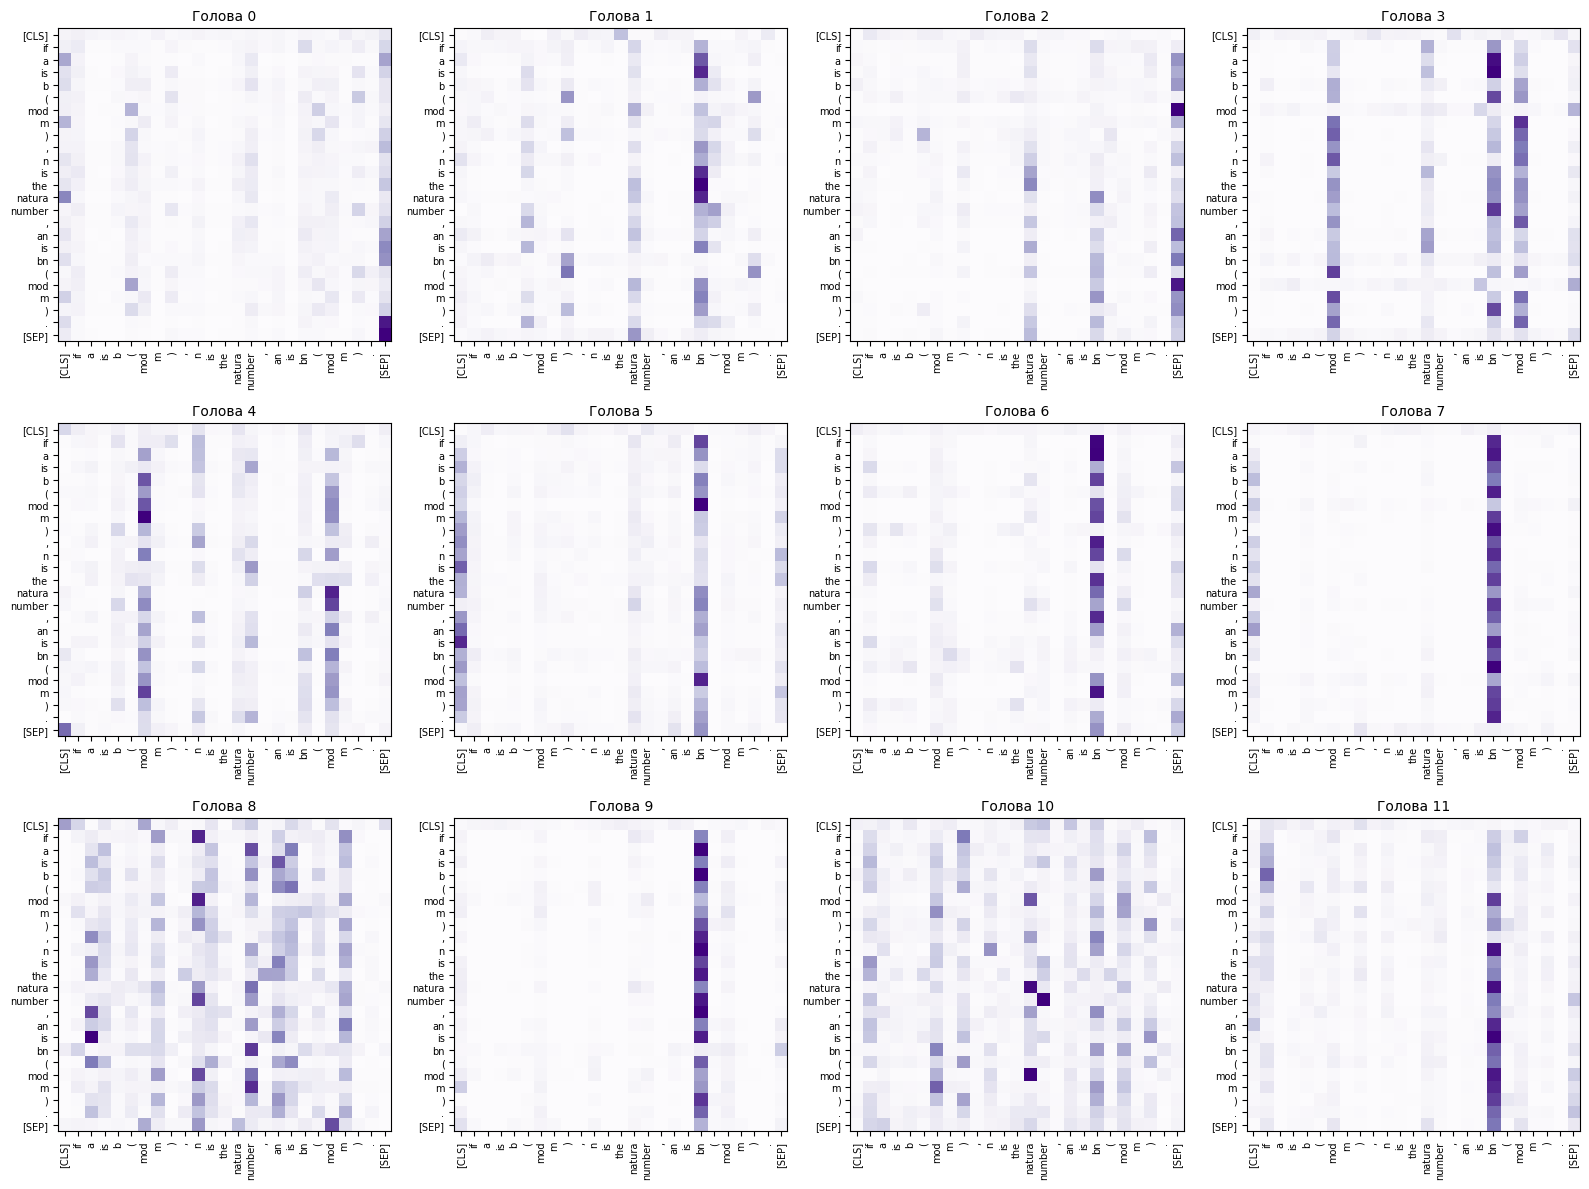


######################################################################
Текст 2: combinatorics
There are 40 signs in the row: 20 crucifixes and 20 nils. You can change the order of any two adjace...
######################################################################


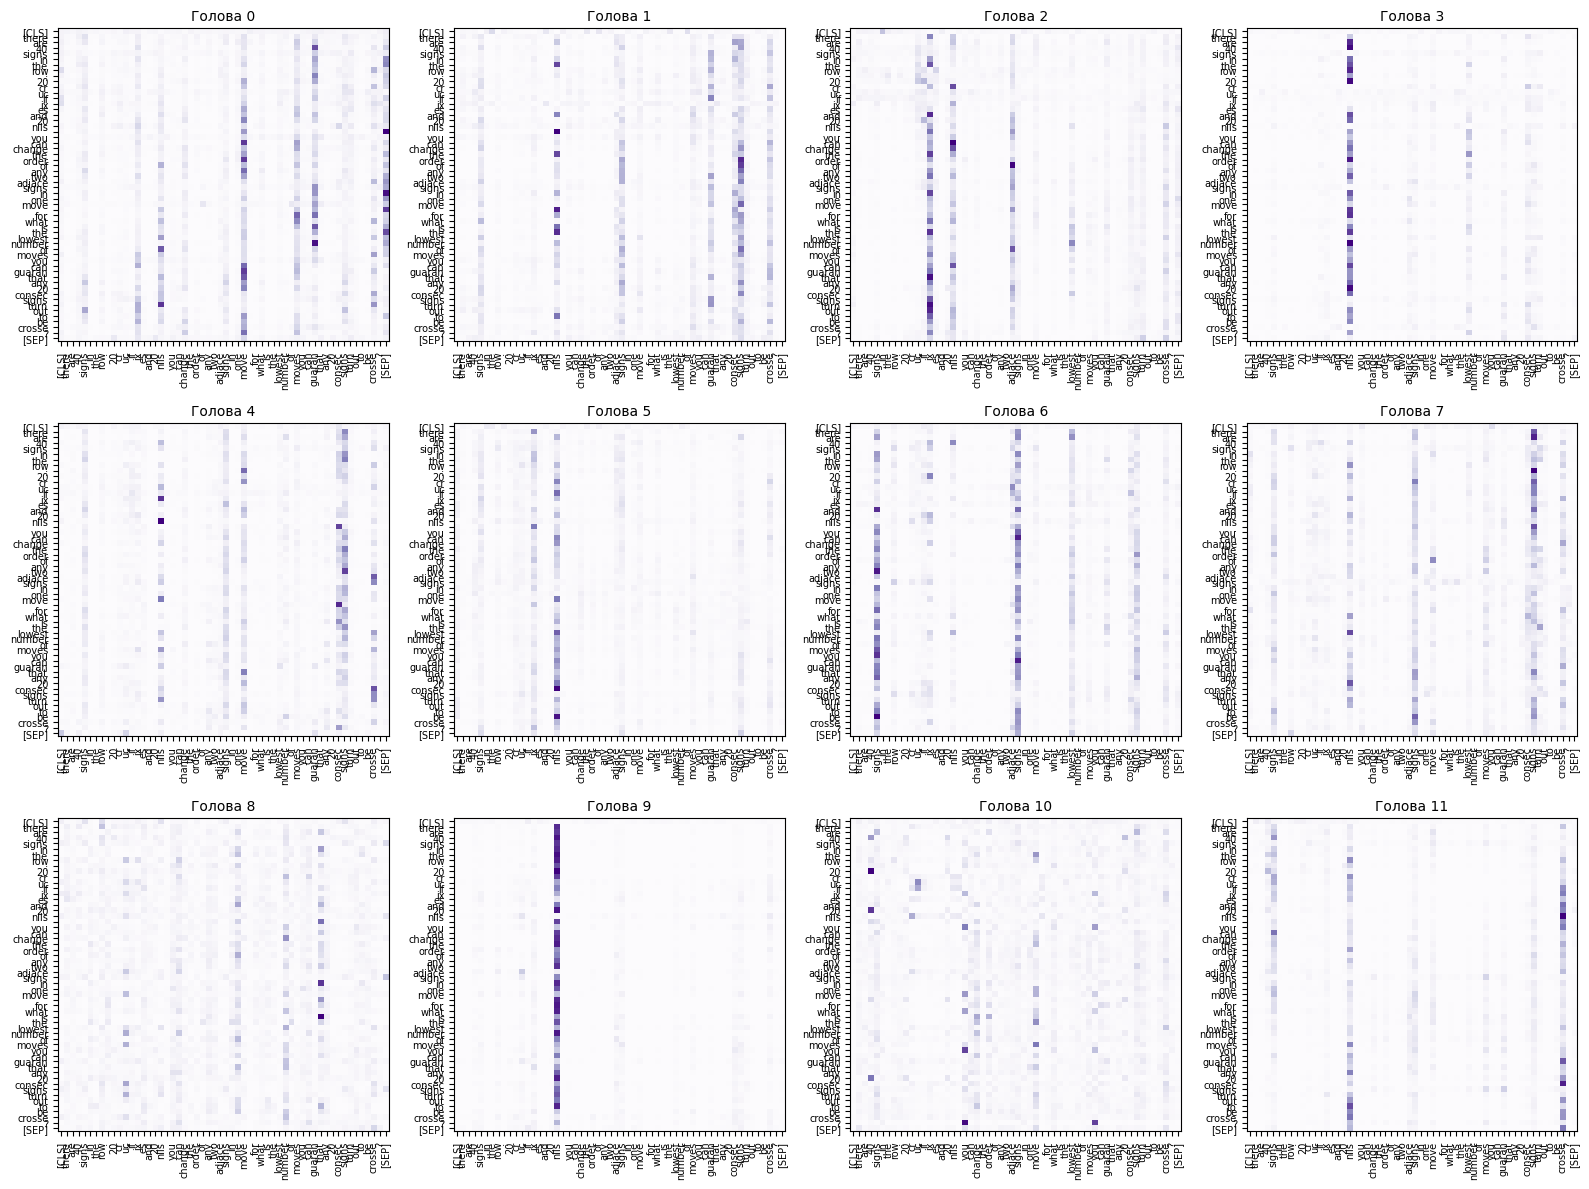


######################################################################
Текст 3: number_theory
Can all natural number dividers of 100! (including 1 and the number itself) be divided into two grou...
######################################################################


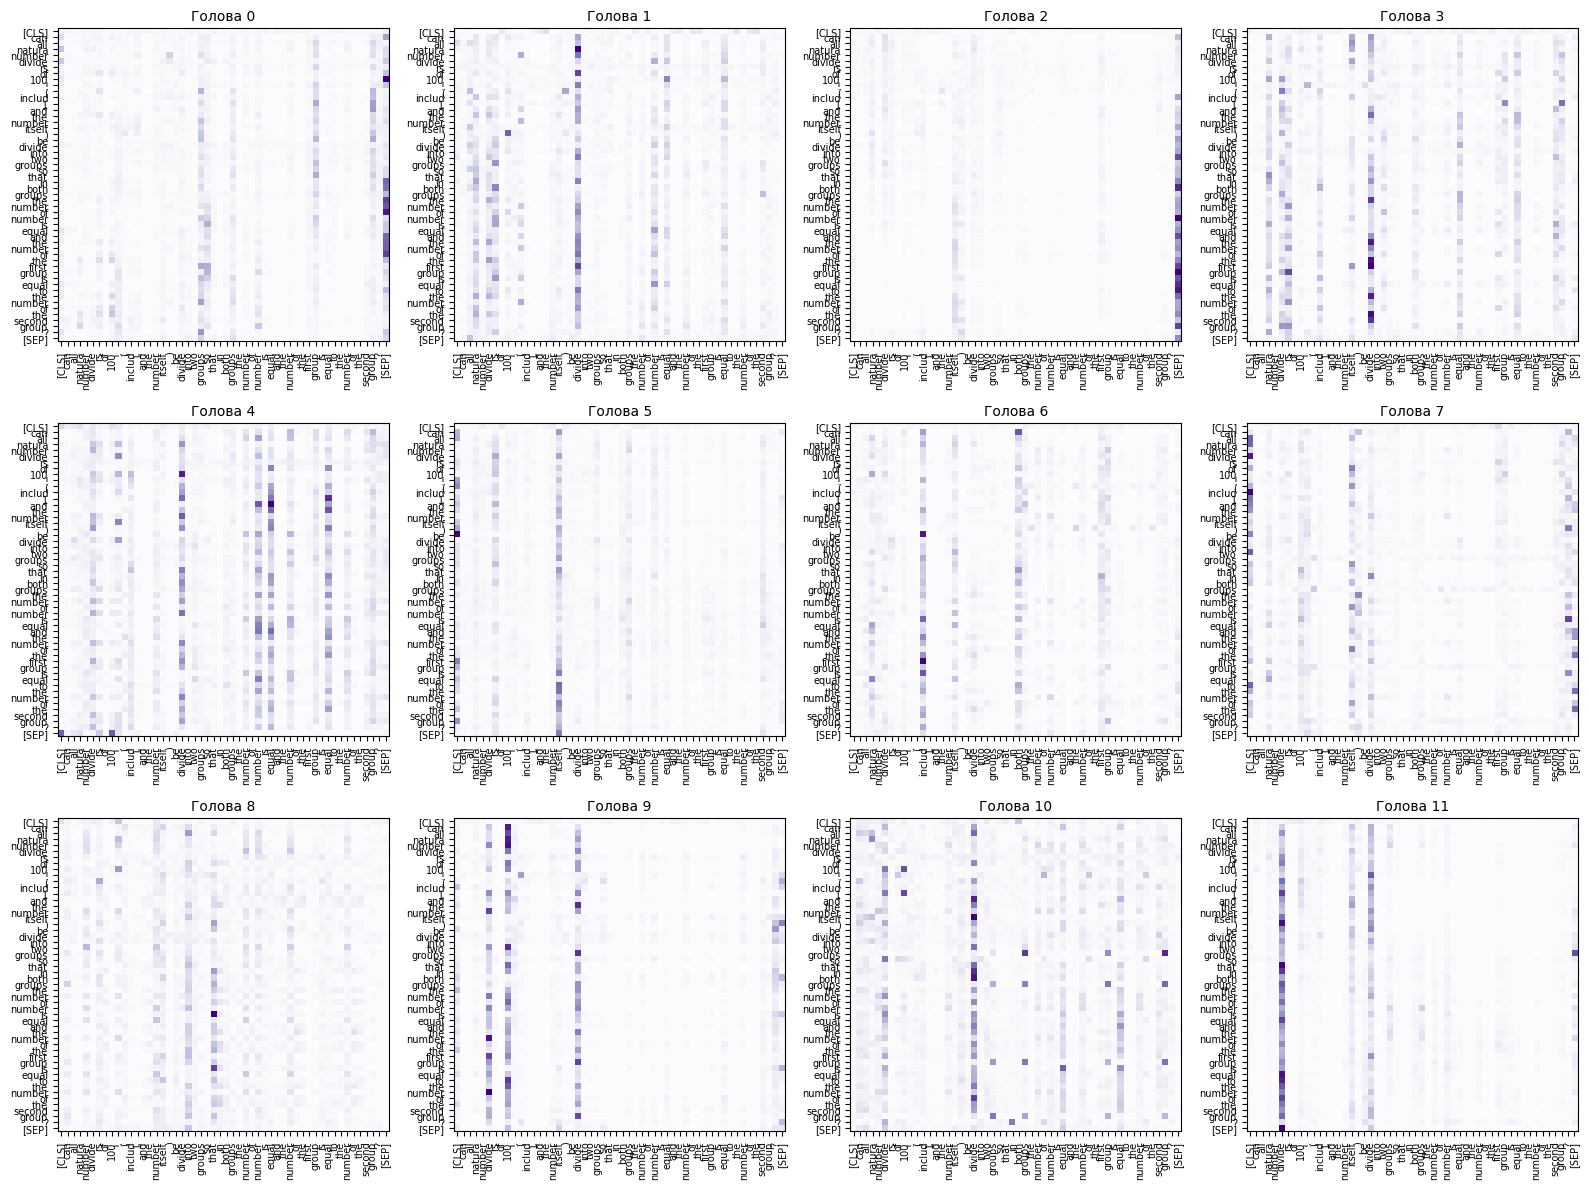

In [ ]:
print("MathBert ДО ОБУЧЕНИЯ")

for i, (text, topic) in enumerate(zip(sample_texts, sample_topics)):
    print(f"\n{'#'*70}")
    print(f"Текст {i+1}: {topic}")
    print(f"{text[:100]}...")
    print(f"{'#'*70}")

    draw_first_layer_attention_maps(
        text=text,
        model=mathbert_raw,
        tokenizer=mathbert_tokenizer,
        cmap='Purples', title_prefix='ДО ОБУЧЕНИЯ'
    )

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?

Выбранные тексты для анализа:

1. Тема: number_theory
   If a is b (mod m), n is the natural number, an is bn (mod m)....

2. Тема: combinatorics
   There are 40 signs in the row: 20 crucifixes and 20 nils. You can change the order of any two adjace...

3. Тема: number_theory
   Can all natural number dividers of 100! (including 1 and the number itself) be divided into two grou...

Устройство: cuda
Дообученные модели rubert-tiny2 готовы

rubert-tiny2 FROZEN (ПОСЛЕ ОБУЧЕНИЯ)

######################################################################
Текст 1: number_theory
If a is b (mod m), n is the natural number, an is bn (mod m)....
######################################################################


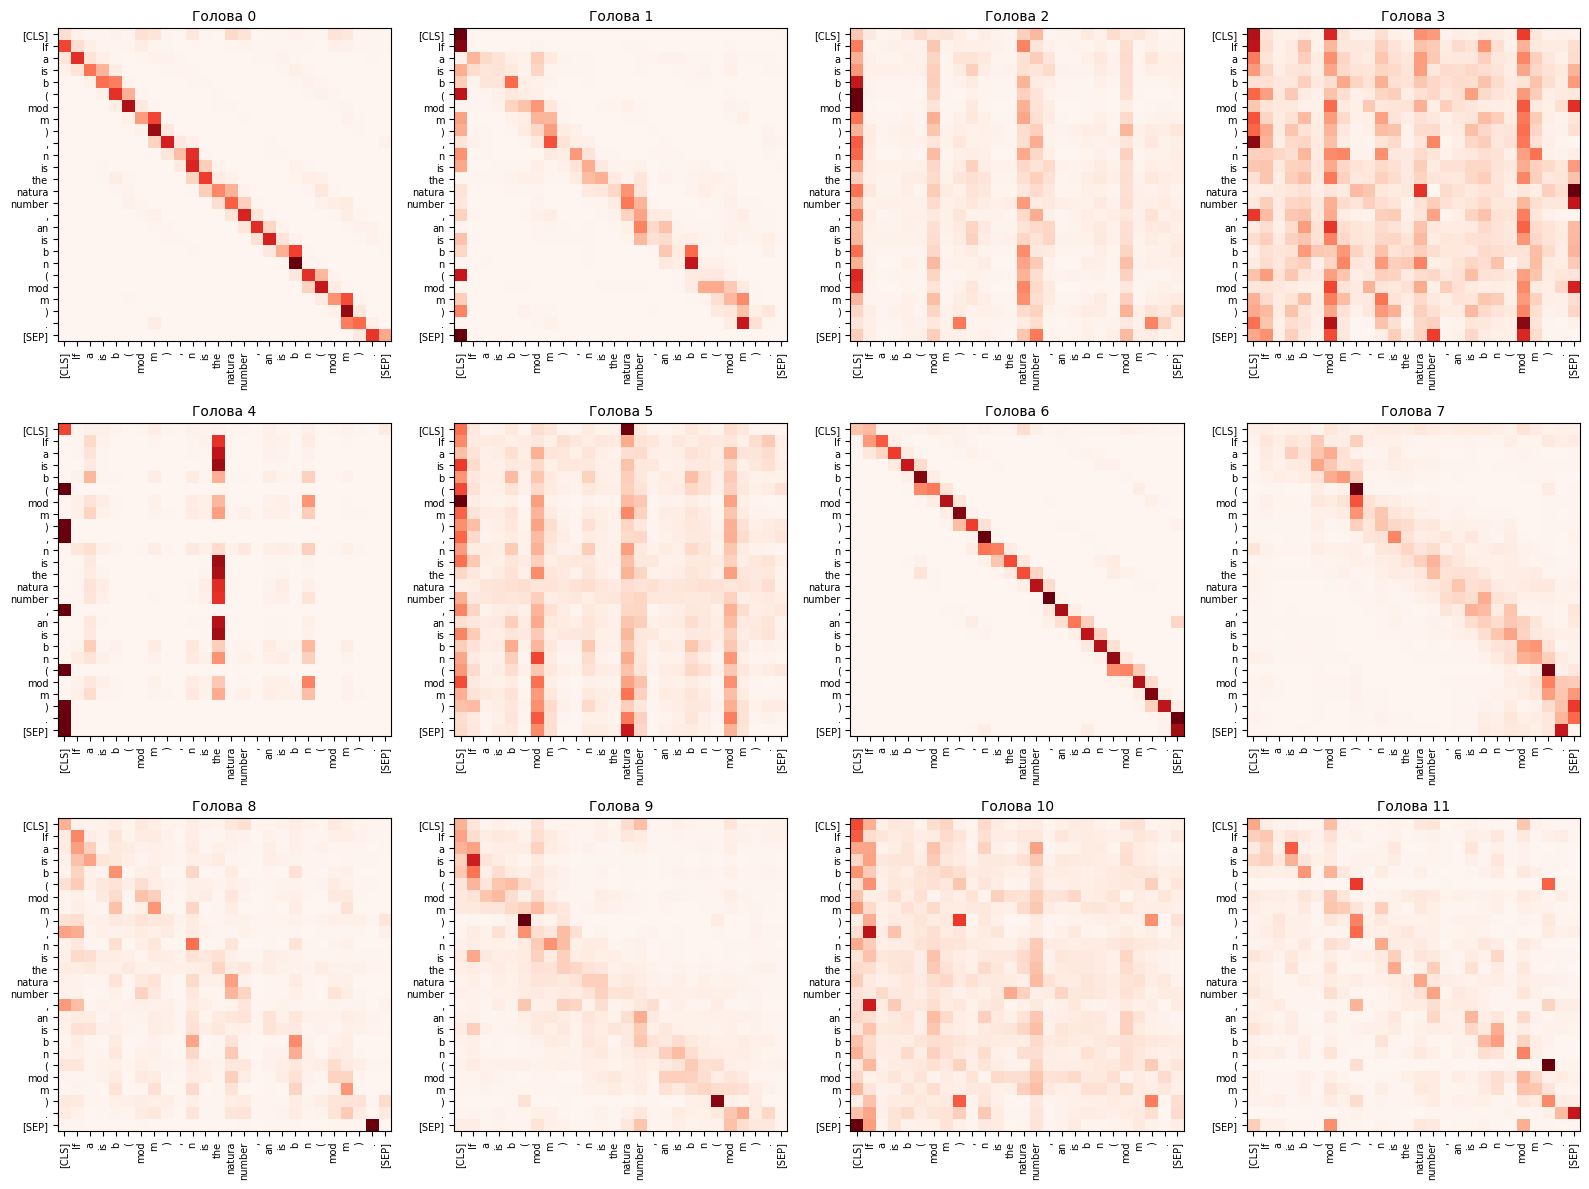


######################################################################
Текст 2: combinatorics
There are 40 signs in the row: 20 crucifixes and 20 nils. You can change the order of any two adjace...
######################################################################


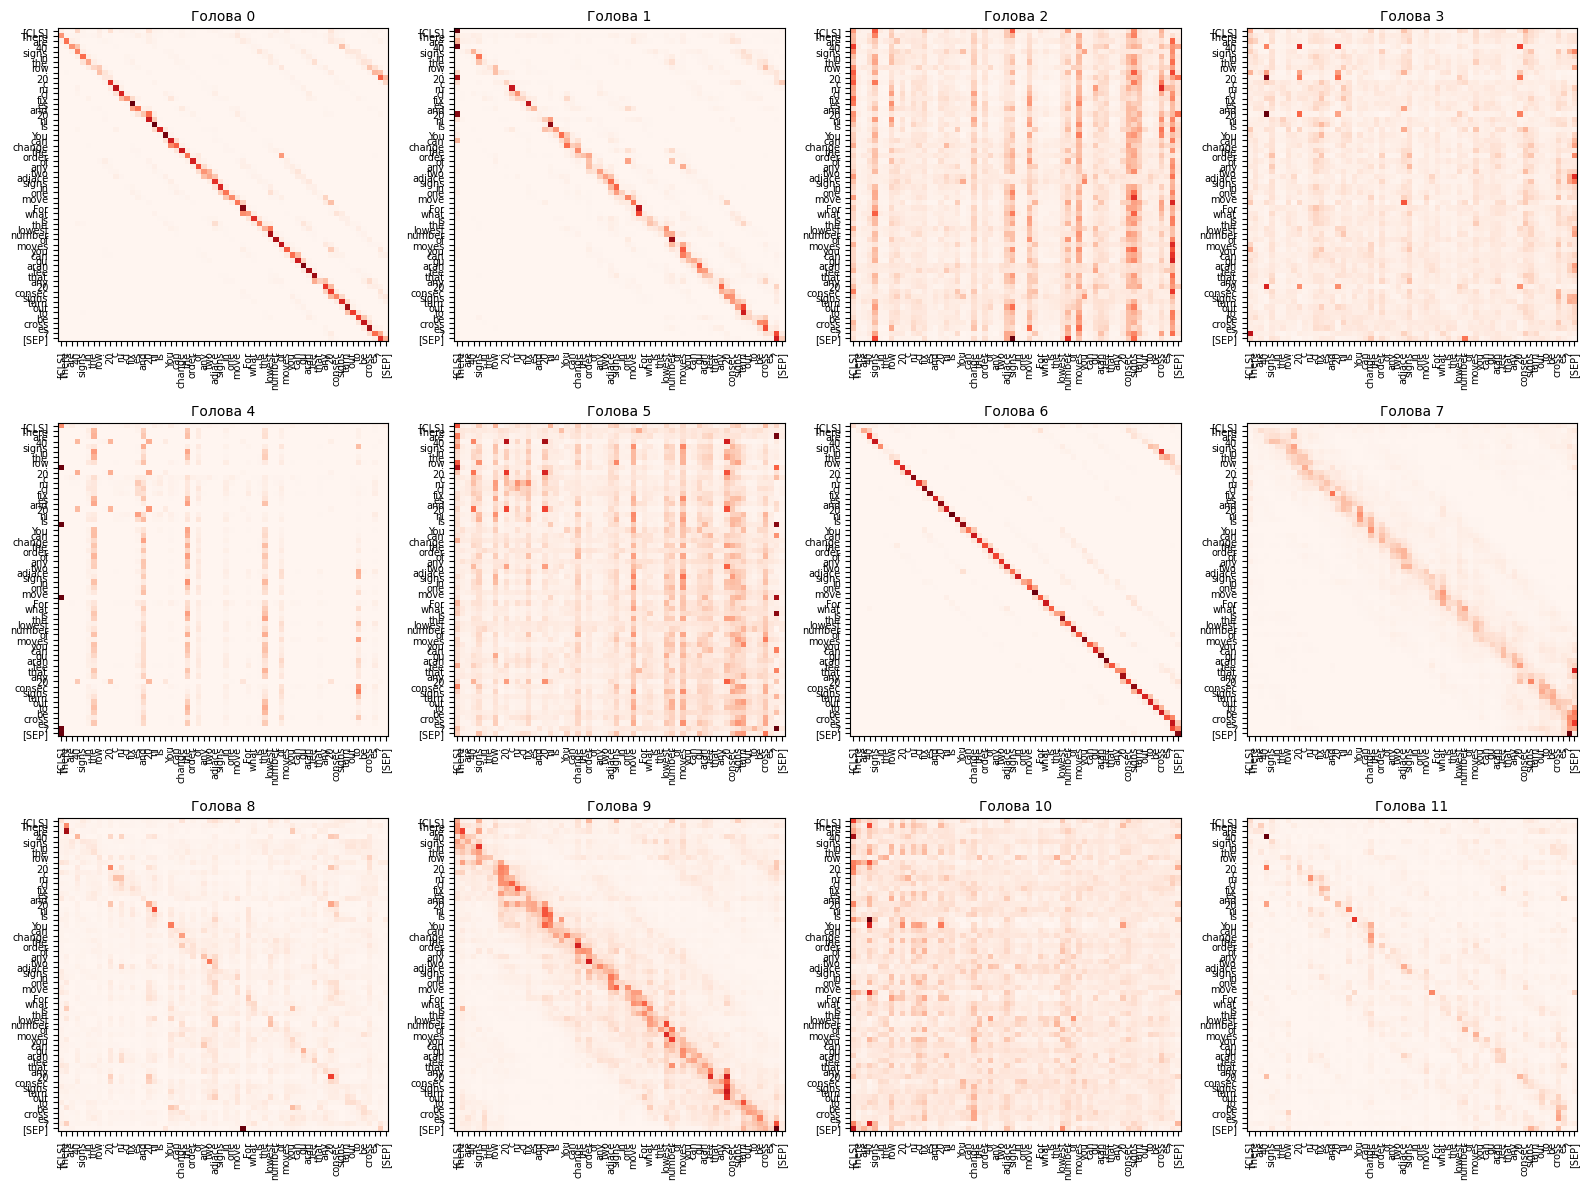


######################################################################
Текст 3: number_theory
Can all natural number dividers of 100! (including 1 and the number itself) be divided into two grou...
######################################################################


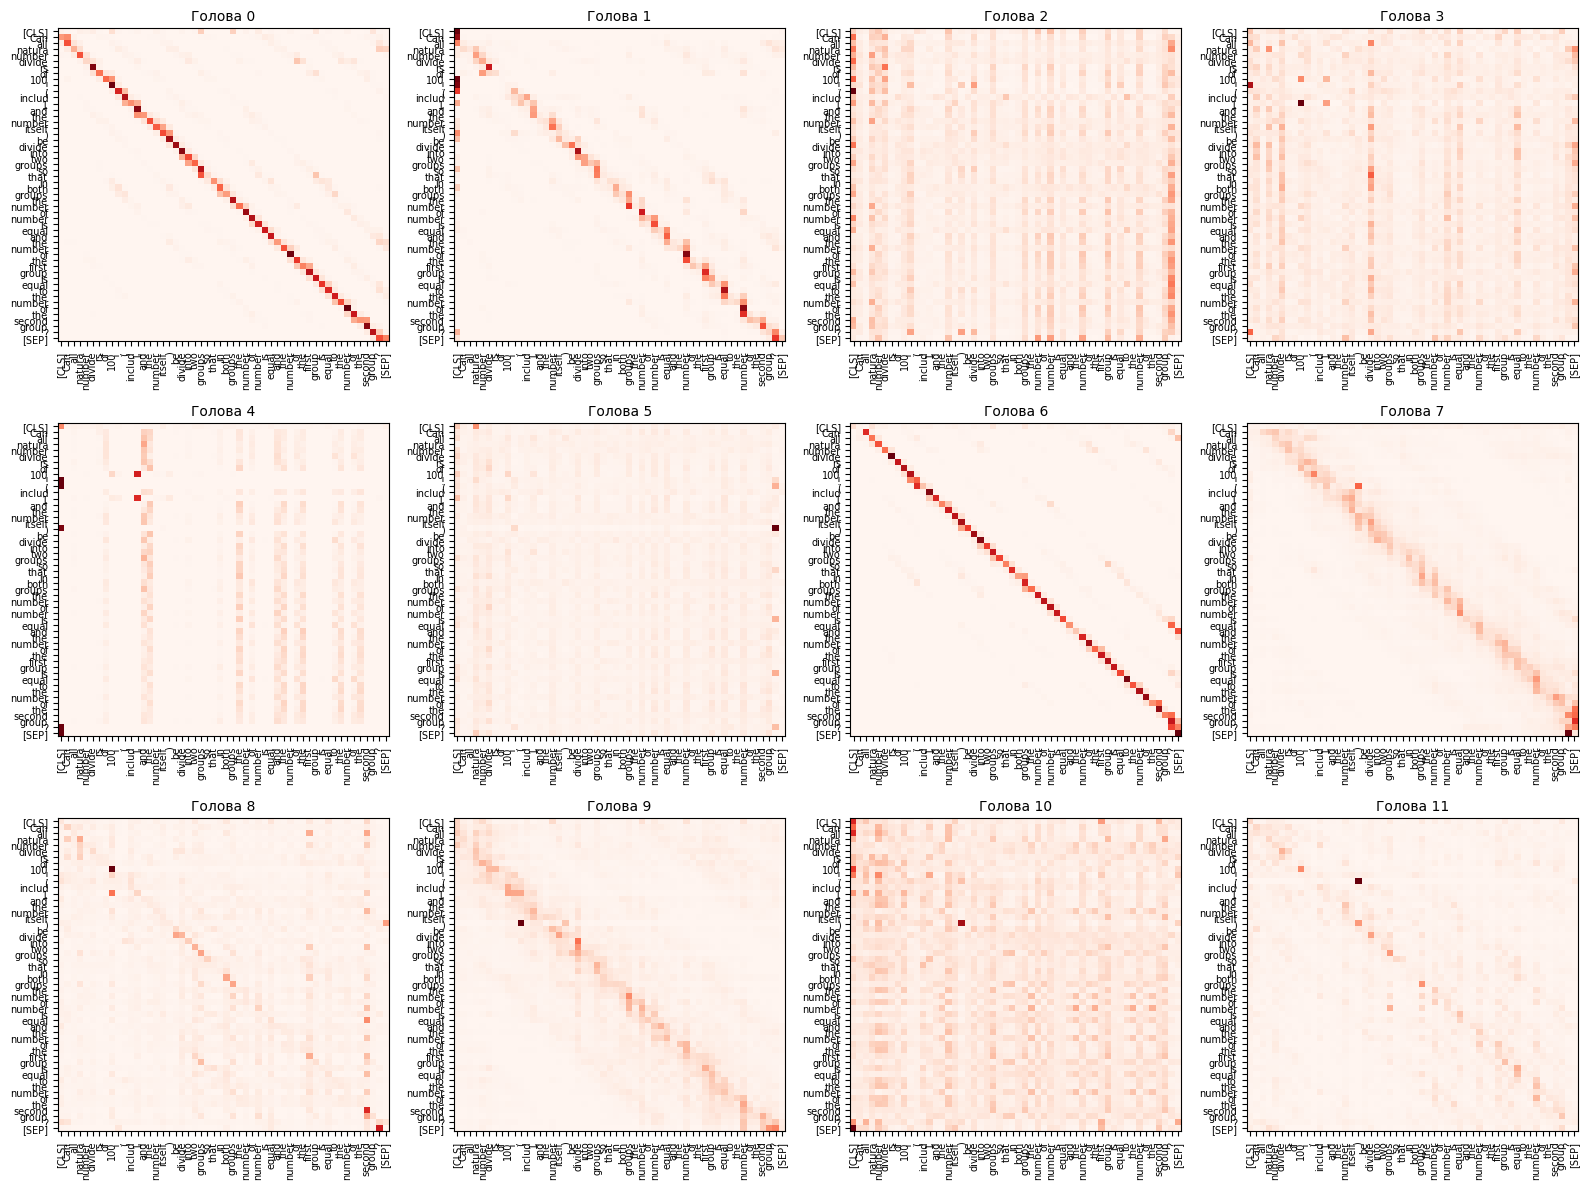


rubert-tiny2 UNFROZEN (ПОСЛЕ ОБУЧЕНИЯ)

######################################################################
Текст 1: number_theory
If a is b (mod m), n is the natural number, an is bn (mod m)....
######################################################################


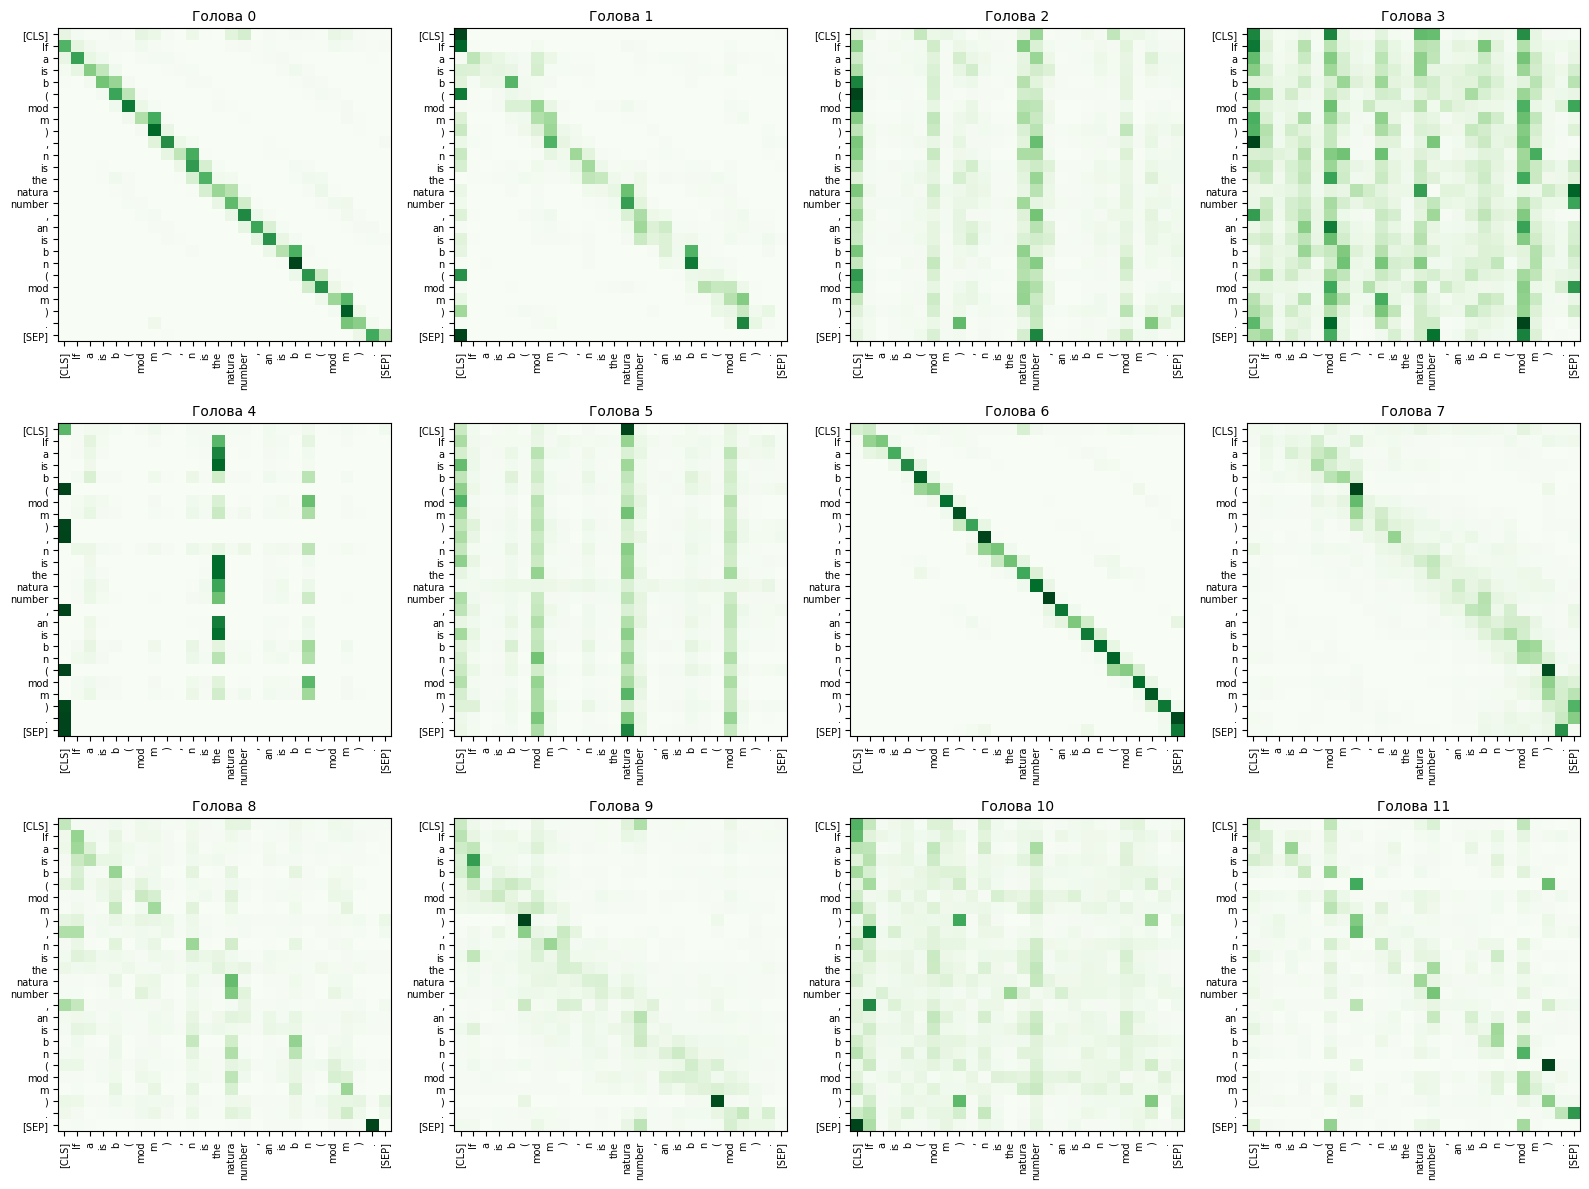


######################################################################
Текст 2: combinatorics
There are 40 signs in the row: 20 crucifixes and 20 nils. You can change the order of any two adjace...
######################################################################


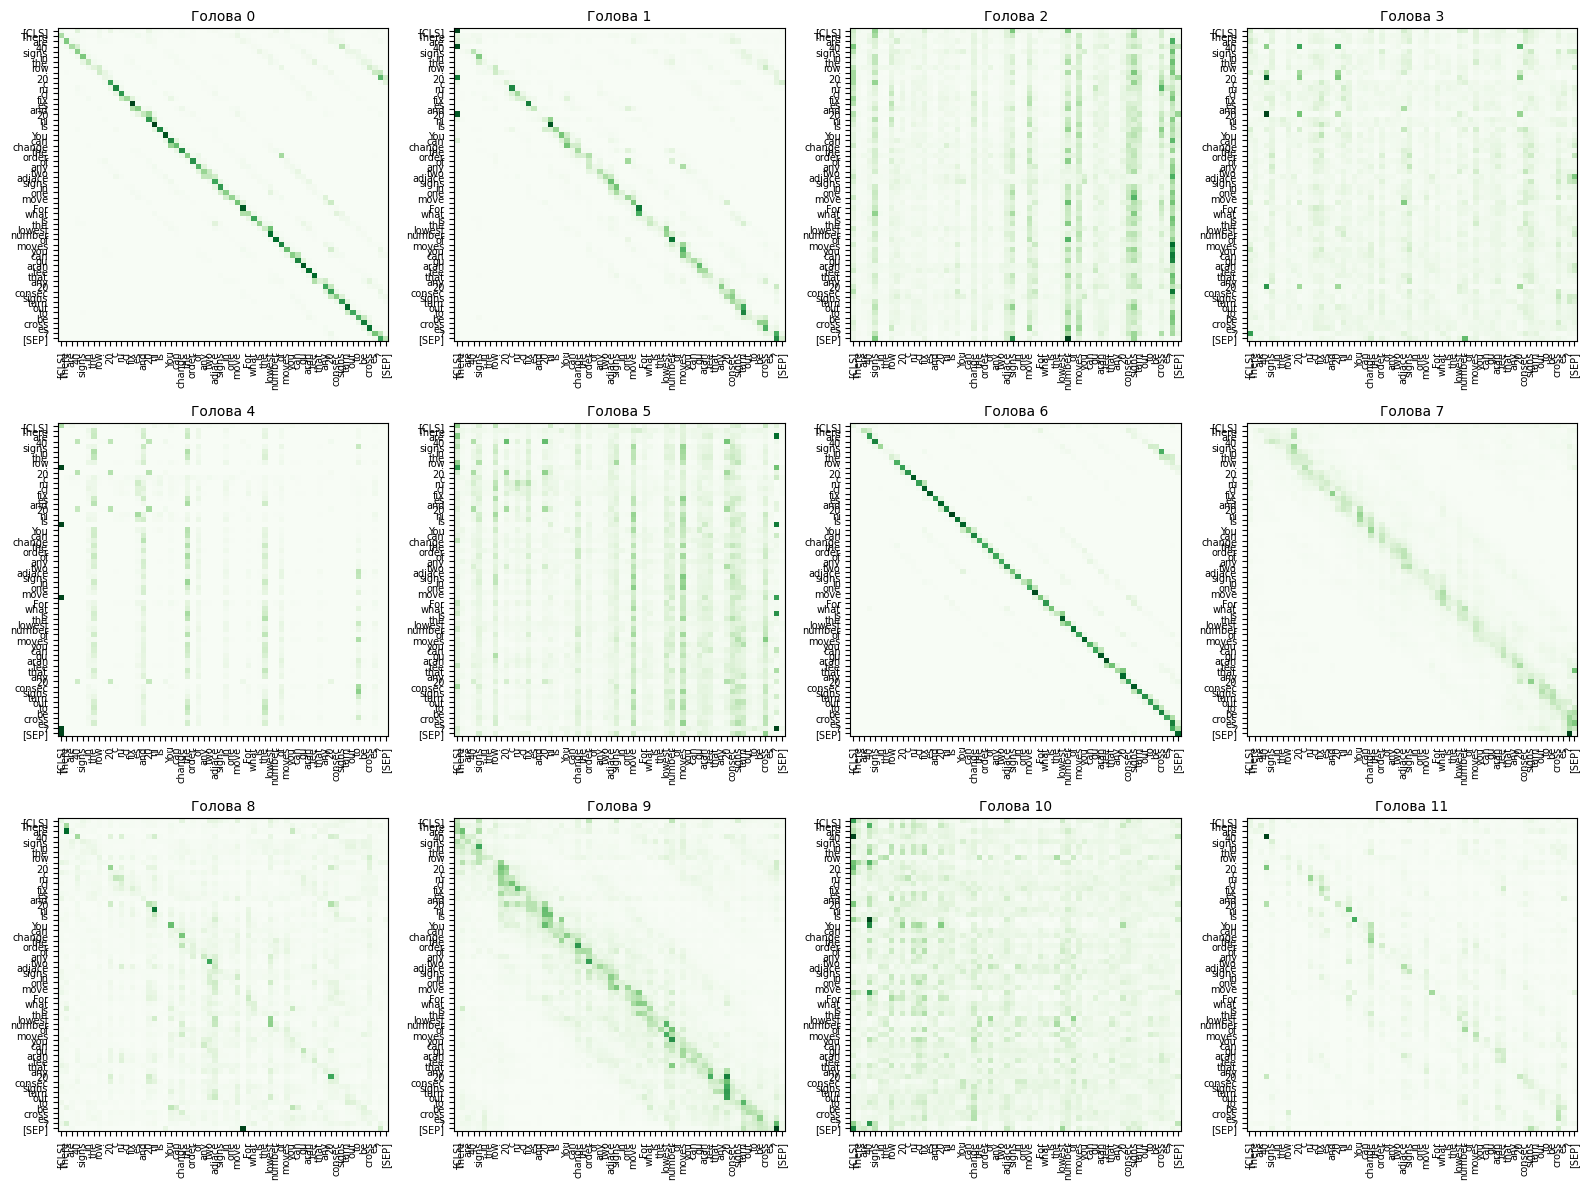


######################################################################
Текст 3: number_theory
Can all natural number dividers of 100! (including 1 and the number itself) be divided into two grou...
######################################################################


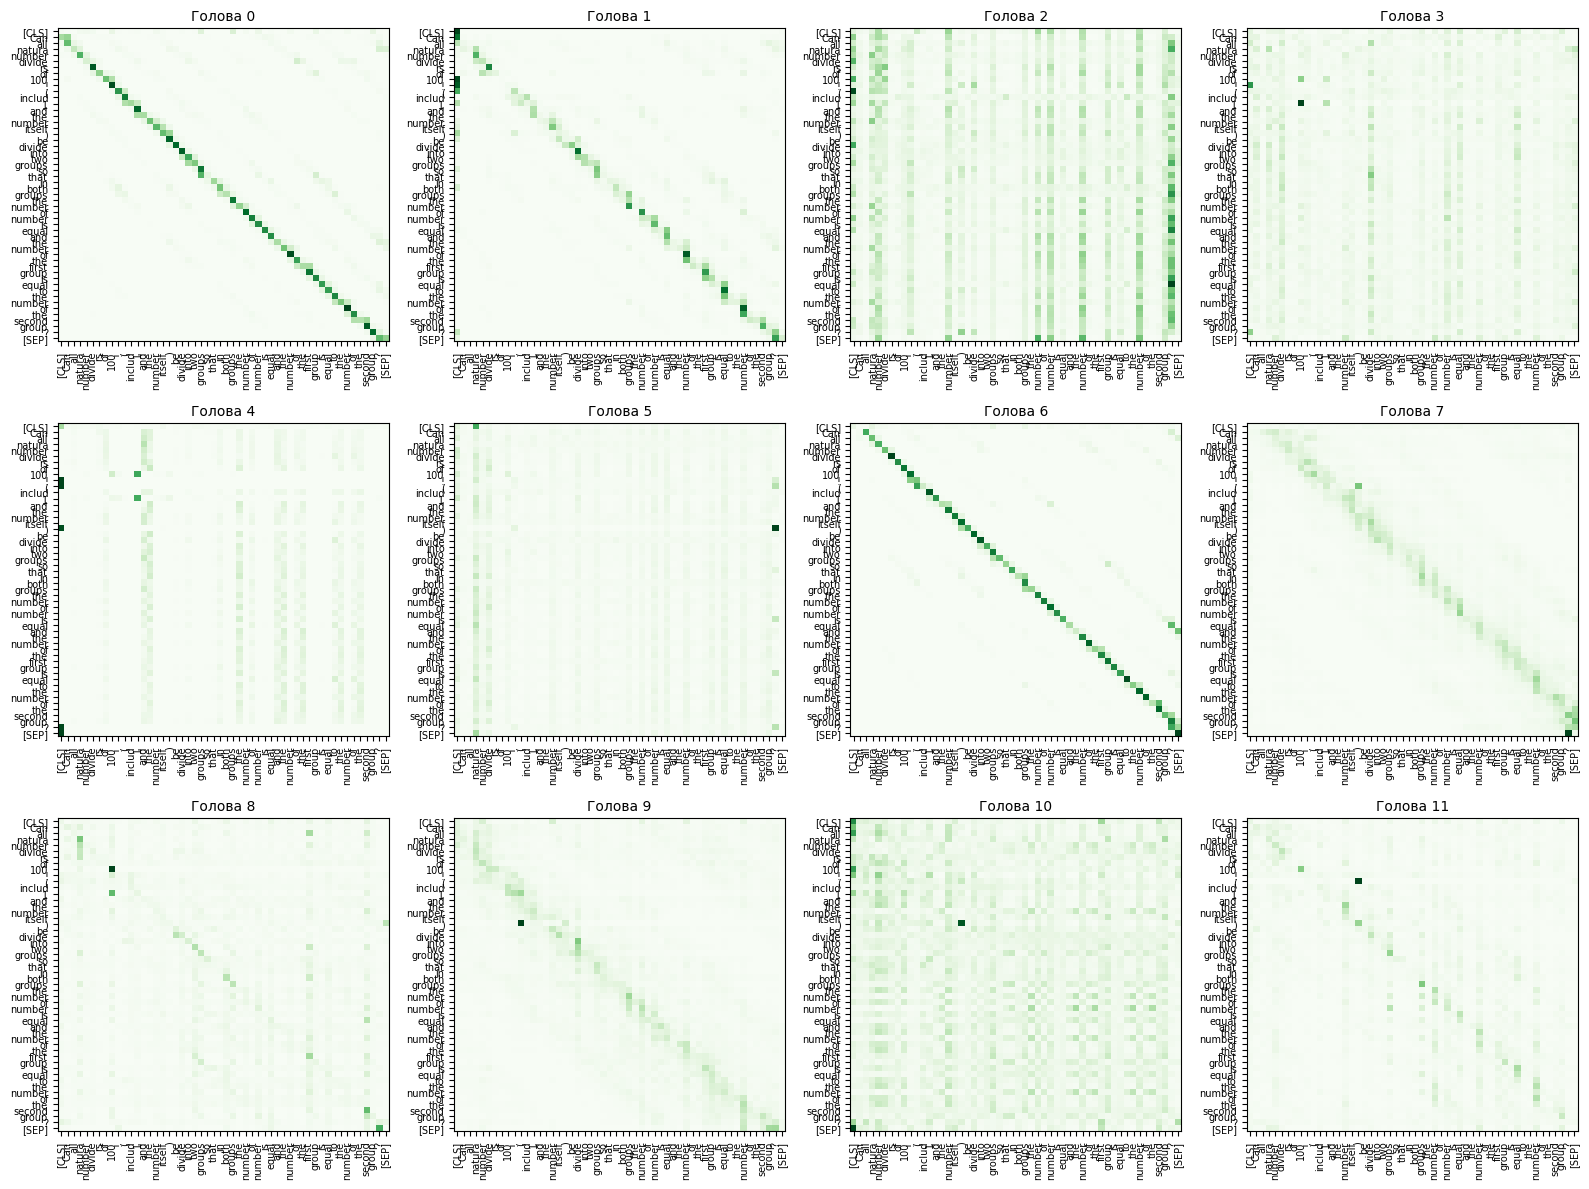

In [ ]:
sample_texts = val_df['problem_text'].values[:3]
sample_topics = val_df['topic'].values[:3]

print("Выбранные тексты для анализа:")
for i, (text, topic) in enumerate(zip(sample_texts, sample_topics)):
    print(f"\n{i+1}. Тема: {topic}")
    print(f"   {text[:100]}...")

#Подготавливаем дообученные модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nУстройство: {device}")

# Переносим обученные модели
rubert_frozen = rubert_tiny_frozen.to(device)
rubert_frozen.eval()

rubert_unfrozen = rubert_tiny_unfrozen.to(device)
rubert_unfrozen.eval()

print("Дообученные модели rubert-tiny2 готовы")

#для rubert-tiny2 FROZEN
print("\n" + "="*70)
print("rubert-tiny2 FROZEN (ПОСЛЕ ОБУЧЕНИЯ)")

for i, (text, topic) in enumerate(zip(sample_texts, sample_topics)):
    print(f"\n{'#'*70}")
    print(f"Текст {i+1}: {topic}")
    print(f"{text[:100]}...")
    print(f"{'#'*70}")

    draw_first_layer_attention_maps(
        text=text,
        model=rubert_frozen,
        tokenizer=ruberttiny_tokenizer,
        cmap='Reds', title_prefix='ДО ОБУЧЕНИЯ'
    )

#для rubert-tiny2 UNFROZEN
print("\n" + "="*70)
print("rubert-tiny2 UNFROZEN (ПОСЛЕ ОБУЧЕНИЯ)")
for i, (text, topic) in enumerate(zip(sample_texts, sample_topics)):
    print(f"\n{'#'*70}")
    print(f"Текст {i+1}: {topic}")
    print(f"{text[:100]}...")
    print(f"{'#'*70}")

    draw_first_layer_attention_maps(
        text=text,
        model=rubert_unfrozen,
        tokenizer=ruberttiny_tokenizer,
        cmap='Greens', title_prefix='ДО ОБУЧЕНИЯ'
    )


MathBert FROZEN (ПОСЛЕ ОБУЧЕНИЯ)

######################################################################
Текст 1: number_theory
If a is b (mod m), n is the natural number, an is bn (mod m)....
######################################################################


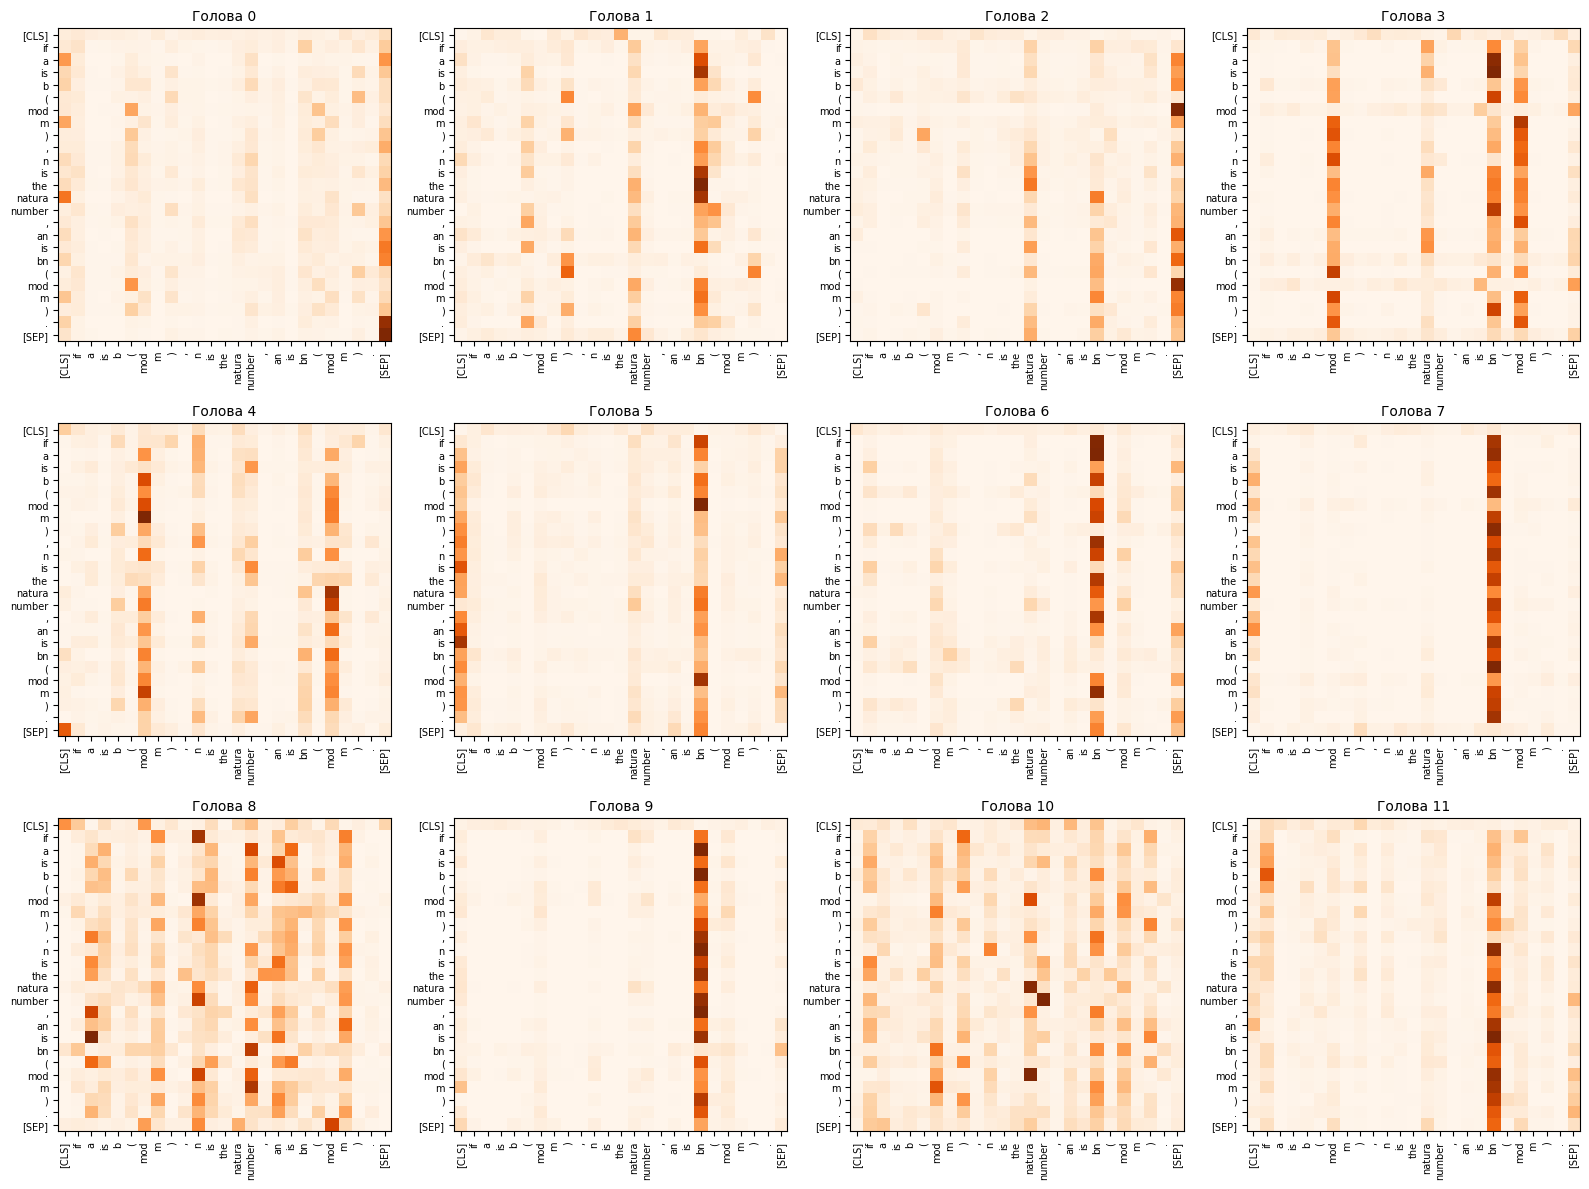


######################################################################
Текст 2: combinatorics
There are 40 signs in the row: 20 crucifixes and 20 nils. You can change the order of any two adjace...
######################################################################


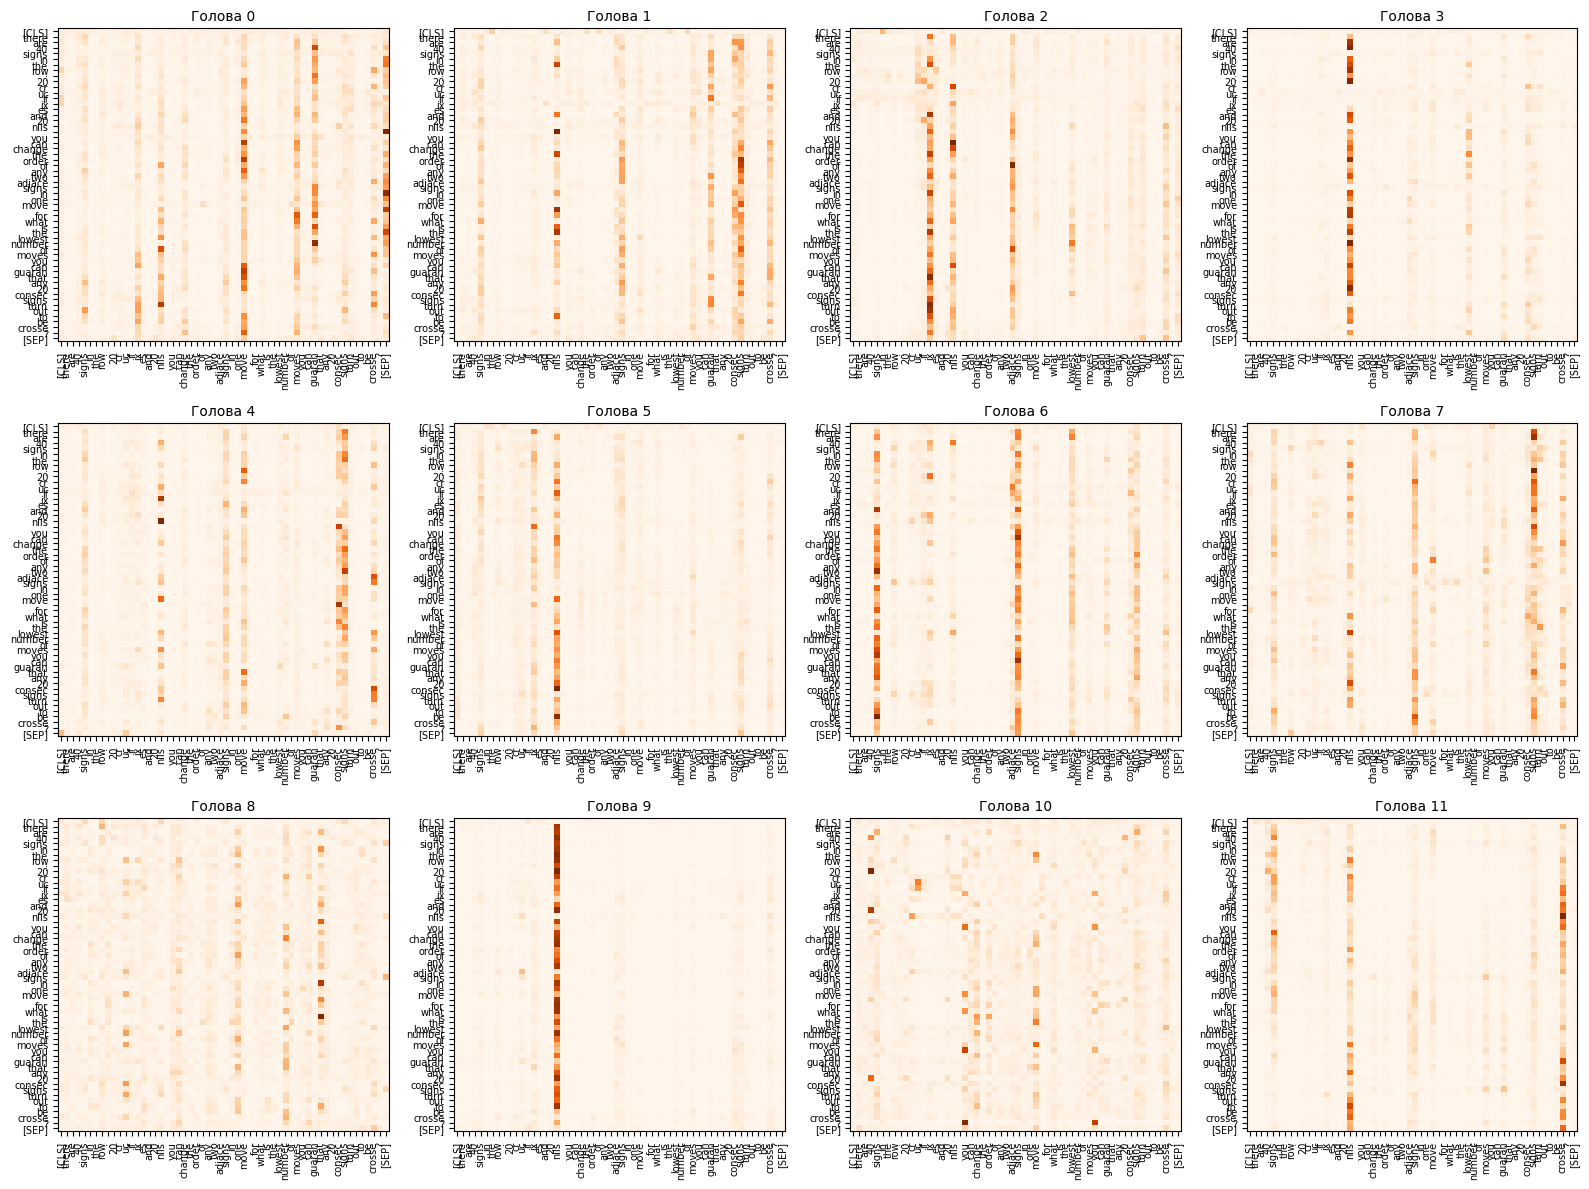


######################################################################
Текст 3: number_theory
Can all natural number dividers of 100! (including 1 and the number itself) be divided into two grou...
######################################################################


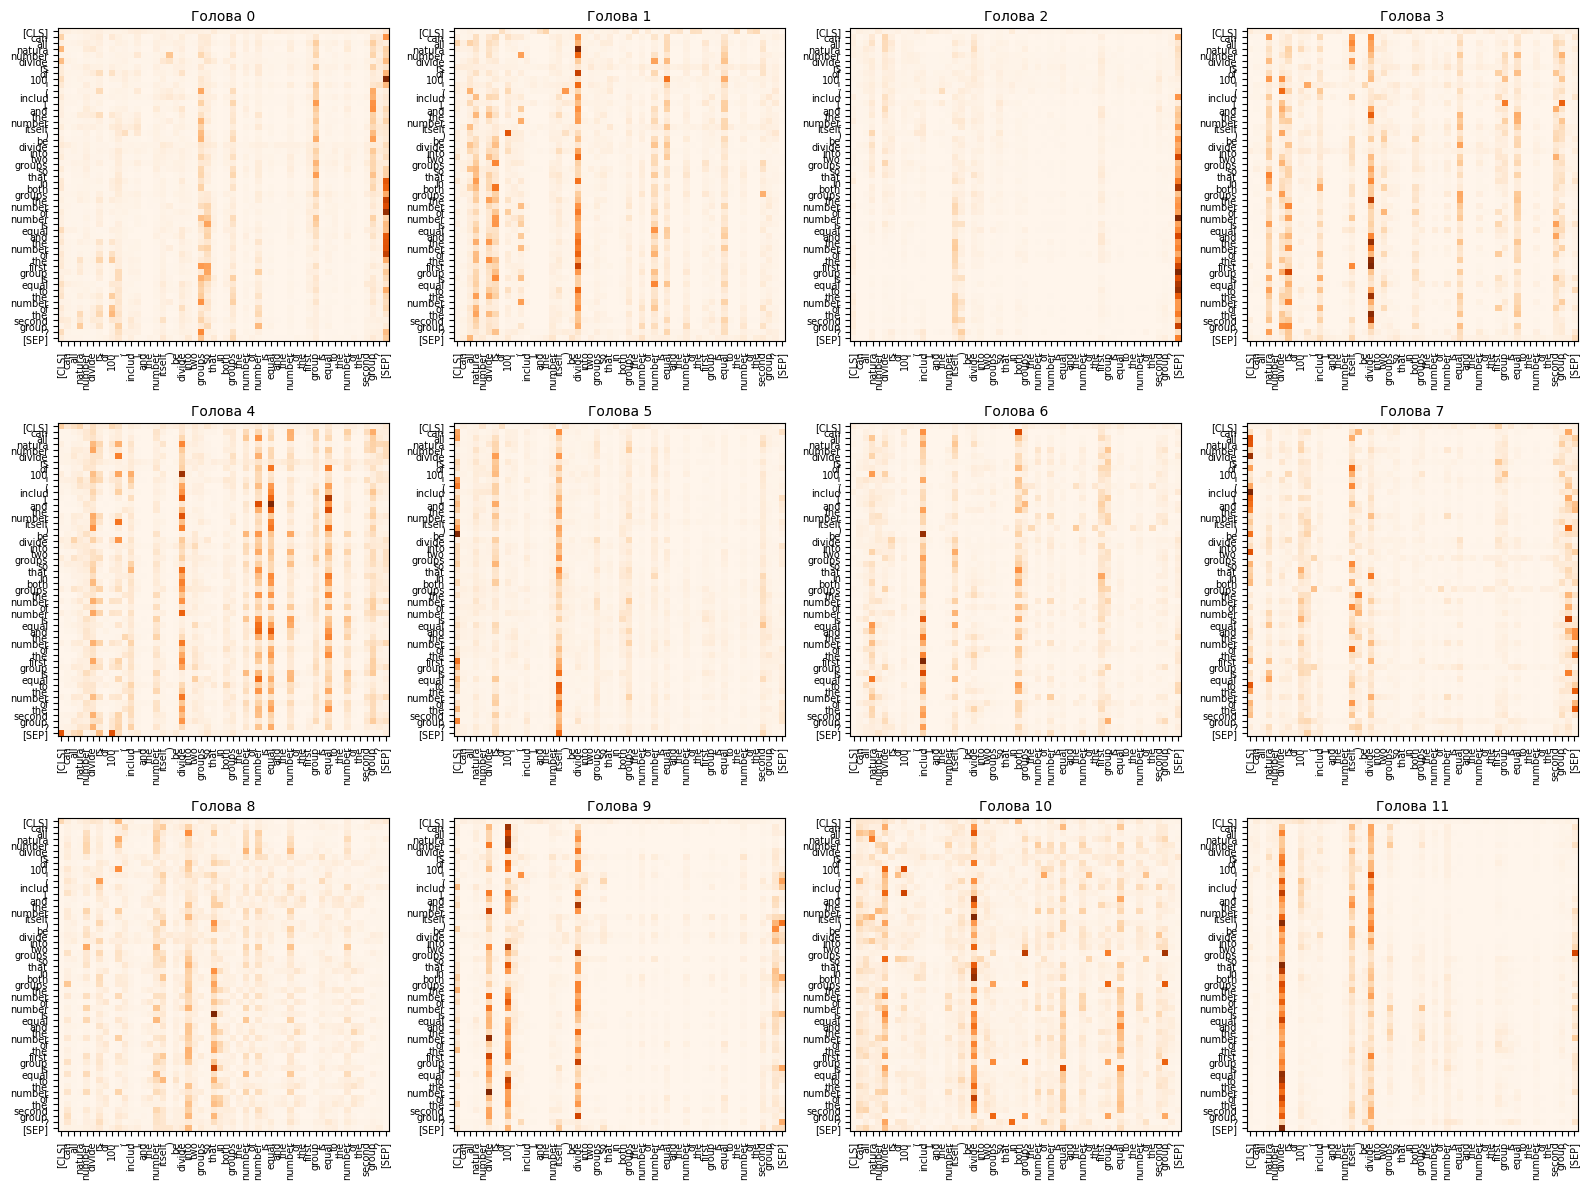


MathBert UNFROZEN (ПОСЛЕ ОБУЧЕНИЯ)

######################################################################
Текст 1: number_theory
If a is b (mod m), n is the natural number, an is bn (mod m)....
######################################################################


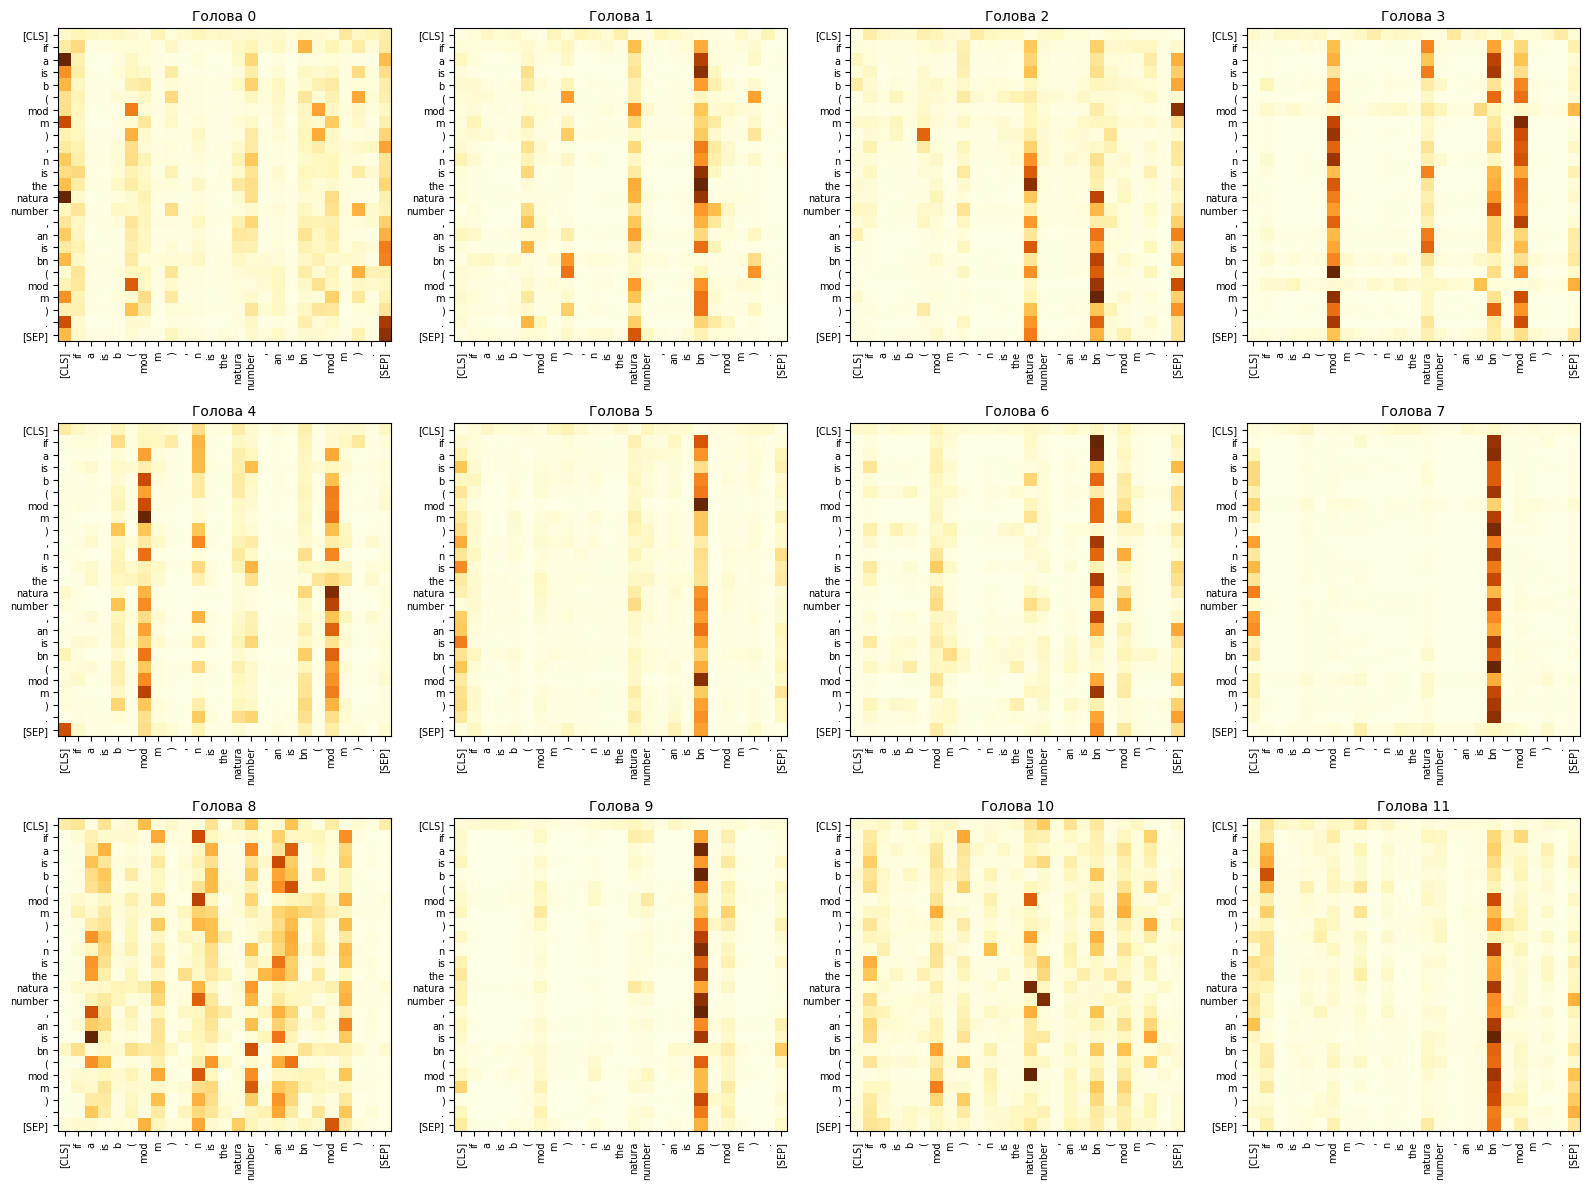


######################################################################
Текст 2: combinatorics
There are 40 signs in the row: 20 crucifixes and 20 nils. You can change the order of any two adjace...
######################################################################


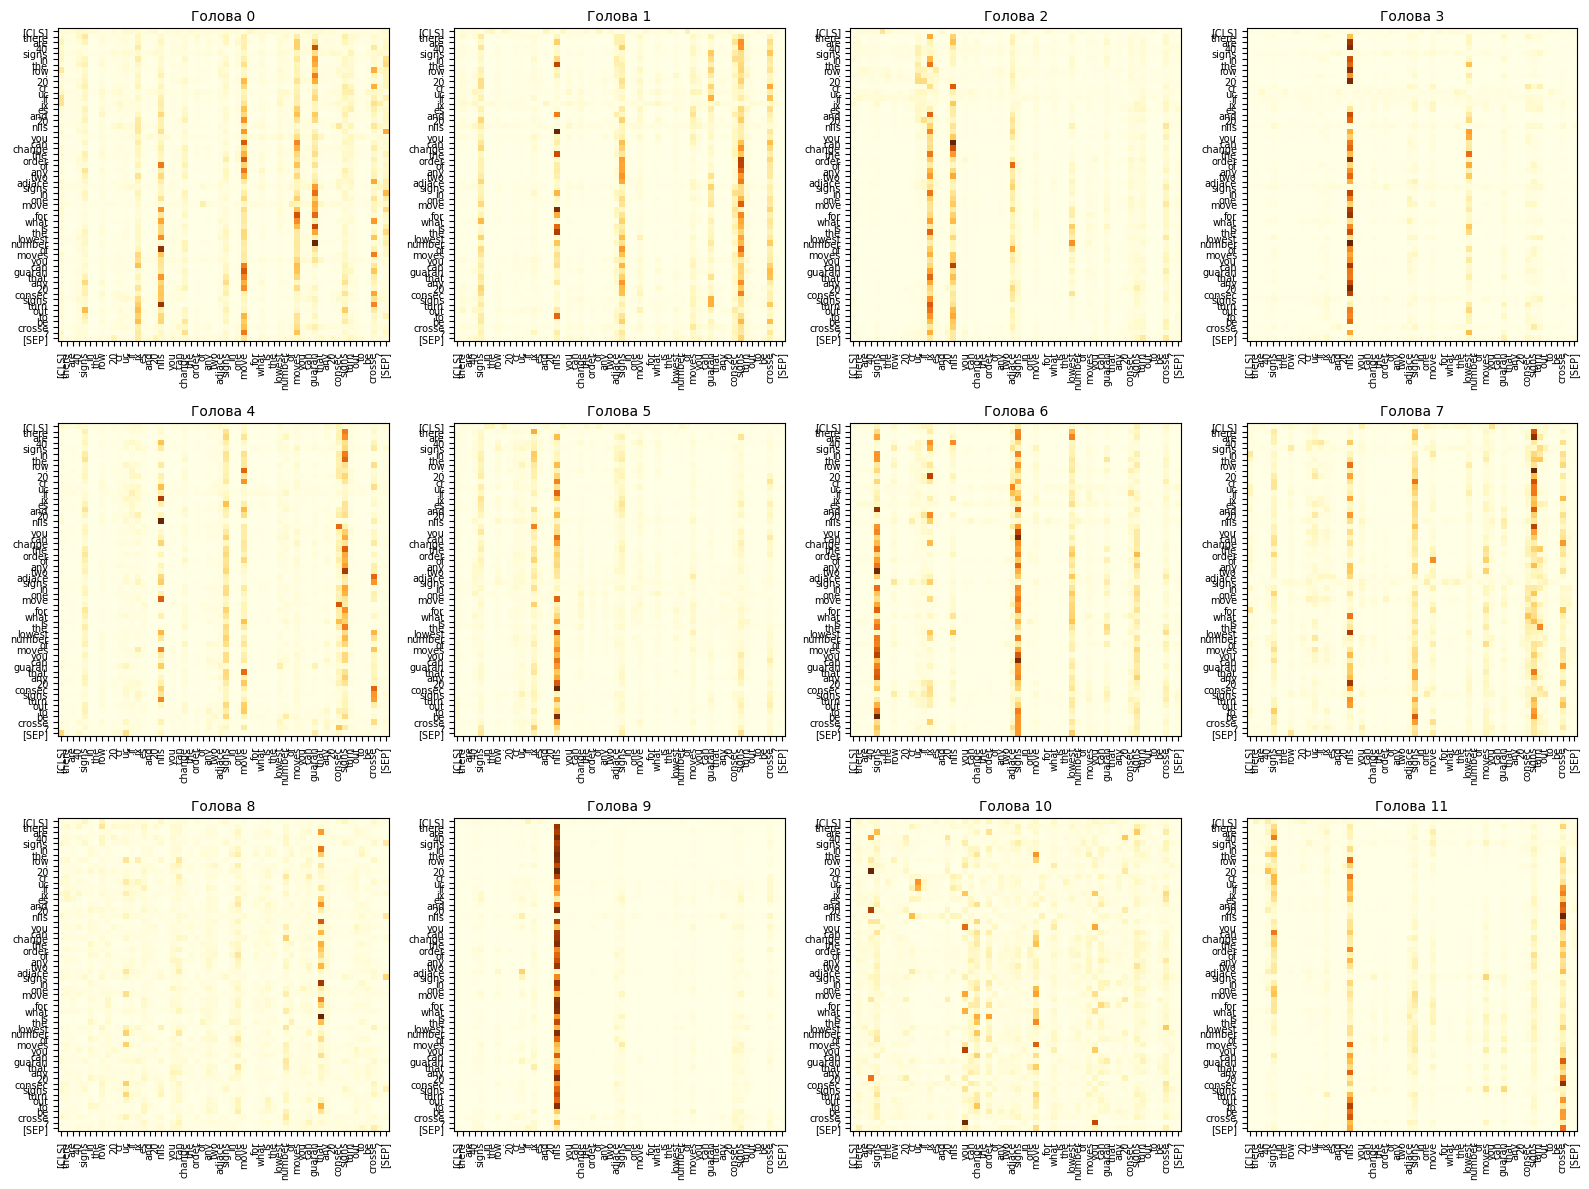


######################################################################
Текст 3: number_theory
Can all natural number dividers of 100! (including 1 and the number itself) be divided into two grou...
######################################################################


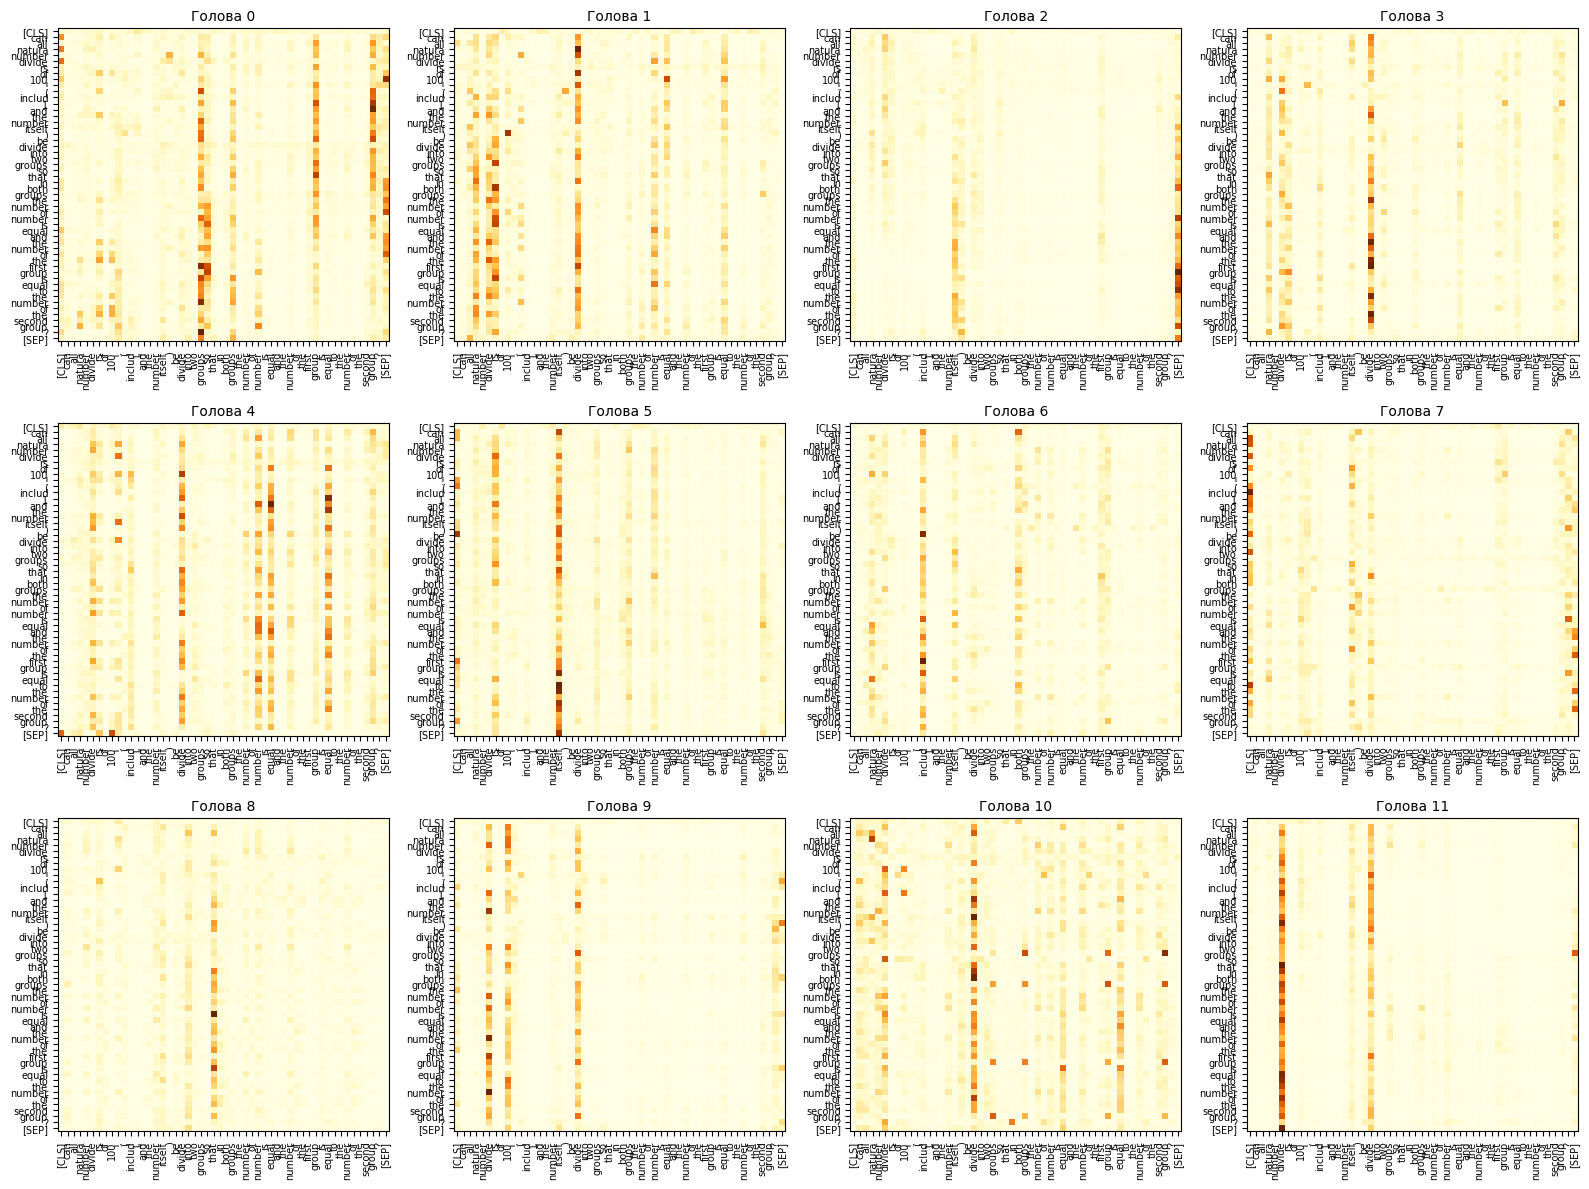

In [ ]:
# Переносим обученные модели MathBert
mathbert_frozen = mathbert_frozen.to(device)
mathbert_frozen.eval()

mathbert_unfrozen = mathbert_unfrozen.to(device)
mathbert_unfrozen.eval()

print("\n" + "="*70)
print("MathBert FROZEN (ПОСЛЕ ОБУЧЕНИЯ)")
print("="*70)

for i, (text, topic) in enumerate(zip(sample_texts, sample_topics)):
    print(f"\n{'#'*70}")
    print(f"Текст {i+1}: {topic}")
    print(f"{text[:100]}...")
    print(f"{'#'*70}")

    draw_first_layer_attention_maps(
        text=text,
        model=mathbert_frozen,
        tokenizer=mathbert_tokenizer,
        cmap='Oranges',
        title_prefix='MathBert ПОСЛЕ ОБУЧЕНИЯ (FROZEN)'
    )

print("\n" + "="*70)
print("MathBert UNFROZEN (ПОСЛЕ ОБУЧЕНИЯ)")
print("="*70)

for i, (text, topic) in enumerate(zip(sample_texts, sample_topics)):
    print(f"\n{'#'*70}")
    print(f"Текст {i+1}: {topic}")
    print(f"{text[:100]}...")
    print(f"{'#'*70}")

    draw_first_layer_attention_maps(
        text=text,
        model=mathbert_unfrozen,
        tokenizer=mathbert_tokenizer,
        cmap='YlOrBr',
        title_prefix='MathBert ПОСЛЕ ОБУЧЕНИЯ (UNFROZEN)'
    )

**Анализ карт внимания**
Визуализация карт внимания первого слоя позволила сделать следующие выводы:

На большинстве тепловых карт наблюдается сильное взаимодействие [CLS]-токена с остальными токенами, что соответствует его предназначению - агрегировать информацию из всей последовательности для последующей классификации.

Различные головы внимания демонстрируют разные паттерны. Некоторые фокусируются на локальных связях, другие - на глобальных, что свидетельствует о способности модели извлекать многообразные признаки из текста.

Сравнение карт внимания до и после дообучения показывает, что в процессе fine-tuning внимание становится более сфокусированным и структурированным. Модель начинает выделять ключевые слова и смысловые конструкции, релевантные для решаемой задачи.


Проделанная работа наглядно демонстрирует критическую важность выбора предобученной модели, соответствующей предметной области. Использование специализированной модели (MathBert) является значительно более эффективным, чем применение универсальной языковой модели. Кроме того, дообучение (fine-tuning) размороженного бэкбона существенно повышает качество модели. Визуализация механизма внимания предоставляет ценный инструмент для интерпретации внутренних процессов, происходящих в модели в ходе обучения.

